<a href="https://colab.research.google.com/github/will001-art-ke/WILL/blob/main/titanic_ship_data_by_OMOKE.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import kagglehub
path = kagglehub.dataset_download("sakshisatre/titanic-dataset")
import pandas as pd
import os

# Assuming the CSV file is named 'Titanic-Dataset.csv' inside the downloaded directory
# We will first list the files in the directory to confirm or find the correct name.

csv_files = [f for f in os.listdir(path) if f.endswith('.csv')]

if not csv_files:
    print(f"No CSV files found in the directory: {path}")
elif len(csv_files) > 1:
    print(f"Multiple CSV files found. Using the first one: {csv_files[0]}")
    file_path = os.path.join(path, csv_files[0])
else:
    file_path = os.path.join(path, csv_files[0])

df = pd.read_csv(file_path)

display(df.head())

Using Colab cache for faster access to the 'titanic-dataset' dataset.
Multiple CSV files found. Using the first one: The Titanic dataset.csv


,1,2,3,4,5,6,7,8,9,10
0,sn,pclass,survived,NaN,gender,age,family,fare,embarked,date
1,1,3,0,Mr. Anthony,male,42,0,7.55,NaN,01-Jan-90
2,1,3,0,Mr. Anthony,male,42,0,7.55,NaN,01-Jan-90
3,2,3,0,Master. Eugene Joseph,male,?,2,20.25,S,02-Jan-90
4,3,2,0,"Abbott, Mr. Rossmore Edward",NaN,NaN,2,**,S,03-Jan-90


In [ ]:
df['10'] = pd.to_datetime(df['10'], errors='coerce')
display(df.head())

/tmp/ipykernel_503/4265451332.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['10'] = pd.to_datetime(df['10'], errors='coerce')


,1,2,3,4,5,6,7,8,9,10
0,sn,pclass,survived,NaN,gender,age,family,fare,embarked,NaT
1,1,3,0,Mr. Anthony,male,42,0,7.55,NaN,1990-01-01
2,1,3,0,Mr. Anthony,male,42,0,7.55,NaN,1990-01-01
3,2,3,0,Master. Eugene Joseph,male,?,2,20.25,S,1990-01-02
4,3,2,0,"Abbott, Mr. Rossmore Edward",NaN,NaN,2,**,S,1990-01-03


In [ ]:
print('--- DataFrame Info ---')
df.info()

print('\n--- Descriptive Statistics ---')
display(df.describe(include='all'))

--- DataFrame Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1302 entries, 0 to 1301
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   1       1302 non-null   object        
 1   2       1302 non-null   object        
 2   3       1302 non-null   object        
 3   4       1301 non-null   object        
 4   5       1301 non-null   object        
 5   6       1045 non-null   object        
 6   7       1300 non-null   object        
 7   8       1300 non-null   object        
 8   9       1296 non-null   object        
 9   10      1301 non-null   datetime64[ns]
dtypes: datetime64[ns](1), object(9)
memory usage: 101.8+ KB

--- Descriptive Statistics ---


,1,2,3,4,5,6,7,8,9,10
count,1302,1302,1302,1301,1301,1045,1300,1300,1296,1301
unique,1301,4,3,1297,3,98,10,283,4,NaN
top,1,3,0,Mr. Anthony,male,24,0,13,S,NaN
freq,2,700,801,2,835,47,781,59,905,NaN
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1991-10-12 00:01:06.410453504
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1990-01-01 00:00:00
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1990-11-21 00:00:00
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1991-10-12 00:00:00
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1992-09-01 00:00:00
max,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1993-07-23 00:00:00


In [ ]:
df = df.rename(columns={'10': 'date'})
display(df.head())

,1,2,3,4,5,6,7,8,9,date
0,sn,pclass,survived,NaN,gender,age,family,fare,embarked,NaT
1,1,3,0,Mr. Anthony,male,42,0,7.55,NaN,1990-01-01
2,1,3,0,Mr. Anthony,male,42,0,7.55,NaN,1990-01-01
3,2,3,0,Master. Eugene Joseph,male,?,2,20.25,S,1990-01-02
4,3,2,0,"Abbott, Mr. Rossmore Edward",NaN,NaN,2,**,S,1990-01-03


In [ ]:
print('--- Missing Values Count ---')
display(df.isnull().sum())

--- Missing Values Count ---


,0
1,0
2,0
3,0
4,1
5,1
6,257
7,2
8,2
9,6
date,1


In [ ]:
# Rename columns to more descriptive names based on common Titanic dataset structure
# and the values observed in the first row of data.
df = df.rename(columns={
    '1': 'passenger_id',
    '2': 'pclass',
    '3': 'survived',
    '4': 'name', # Assuming '4' is 'name' based on typical Titanic datasets
    '5': 'gender',
    '6': 'age',
    '7': 'sibsp_parch', # Likely combines SibSp and Parch values for family size
    '8': 'fare',
    '9': 'embarked'
})

# Drop the first row which contained the actual column names as data
df = df.drop(index=0).reset_index(drop=True)

print("--- DataFrame after renaming columns and dropping header row ---")
display(df.head())

--- DataFrame after renaming columns and dropping header row ---


,passenger_id,pclass,survived,name,gender,age,sibsp_parch,fare,embarked,date
0,1,3,0,Mr. Anthony,male,42,0,7.55,NaN,1990-01-01
1,2,3,0,Master. Eugene Joseph,male,?,2,20.25,S,1990-01-02
2,3,2,0,"Abbott, Mr. Rossmore Edward",NaN,NaN,2,**,S,1990-01-03
3,4,3,1,"Abbott, Mr. Rossmore Edward",female,35,2,20.25,S,1990-01-04
4,5,3,1,"Abelseth, Miss. Karen Marie",female,16,0,7.65,S,1990-01-05


In [ ]:
# Convert 'pclass' and 'survived' to numeric types
df['pclass'] = pd.to_numeric(df['pclass'], errors='coerce')
df['survived'] = pd.to_numeric(df['survived'], errors='coerce')

# 'age' - replace '?' with NaN and convert to numeric
df['age'] = df['age'].replace('?', pd.NA)
df['age'] = pd.to_numeric(df['age'], errors='coerce')

# 'sibsp_parch' - replace '?' with NaN (if any) and convert to numeric
df['sibsp_parch'] = df['sibsp_parch'].replace('?', pd.NA)
df['sibsp_parch'] = pd.to_numeric(df['sibsp_parch'], errors='coerce')

# 'fare' - replace '**' with NaN and convert to numeric
df['fare'] = df['fare'].replace('**', pd.NA)
df['fare'] = pd.to_numeric(df['fare'], errors='coerce')

print("\n--- DataFrame info after type conversions ---")
df.info()
print("\n--- Missing values after type conversions ---")
display(df.isnull().sum())


--- DataFrame info after type conversions ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1300 entries, 0 to 1299
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   passenger_id  1300 non-null   object        
 1   pclass        1300 non-null   int64         
 2   survived      1300 non-null   int64         
 3   name          1300 non-null   object        
 4   gender        1299 non-null   object        
 5   age           1042 non-null   float64       
 6   sibsp_parch   1298 non-null   float64       
 7   fare          1297 non-null   float64       
 8   embarked      1295 non-null   object        
 9   date          1300 non-null   datetime64[ns]
dtypes: datetime64[ns](1), float64(3), int64(2), object(4)
memory usage: 101.7+ KB

--- Missing values after type conversions ---


,0
passenger_id,0
pclass,0
survived,0
name,0
gender,1
age,258
sibsp_parch,2
fare,3
embarked,5
date,0


In [ ]:
print("\n--- Imputing missing values ---")

for column in df.columns:
    if df[column].isnull().any(): # Check if there are any missing values in the column
        if pd.api.types.is_numeric_dtype(df[column]):
            # Impute numeric columns with median
            median_val = df[column].median()
            df[column].fillna(median_val, inplace=True)
            print(f"Imputed '{column}' with median: {median_val}")
        elif pd.api.types.is_datetime64_any_dtype(df[column]):
            # Impute datetime columns with mode
            mode_val = df[column].mode()[0]
            df[column].fillna(mode_val, inplace=True)
            print(f"Imputed '{column}' with mode: {mode_val}")
        else:
            # Impute object/categorical columns with mode
            # Exclude 'name' as it's unlikely to be meaningfully imputed by mode
            if column != 'name':
                mode_val = df[column].mode()[0]
                df[column].fillna(mode_val, inplace=True)
                print(f"Imputed '{column}' with mode: {mode_val}")
            else:
                print(f"Skipping imputation for '{column}' (name column). If needed, specific strategy can be applied).")

print("\n--- Missing values after imputation ---")
display(df.isnull().sum())
print("\n--- DataFrame head after imputation ---")
display(df.head())


--- Imputing missing values ---
Imputed 'gender' with mode: male
Imputed 'age' with median: 28.0
Imputed 'sibsp_parch' with median: 0.0
Imputed 'fare' with median: 14.4542
Imputed 'embarked' with mode: S

--- Missing values after imputation ---


/tmp/ipykernel_503/753993405.py:20: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[column].fillna(mode_val, inplace=True)
/tmp/ipykernel_503/753993405.py:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.

,0
passenger_id,0
pclass,0
survived,0
name,0
gender,0
age,0
sibsp_parch,0
fare,0
embarked,0
date,0



--- DataFrame head after imputation ---


,passenger_id,pclass,survived,name,gender,age,sibsp_parch,fare,embarked,date
0,1,3,0,Mr. Anthony,male,42.0,0.0,7.5500,S,1990-01-01
1,2,3,0,Master. Eugene Joseph,male,28.0,2.0,20.2500,S,1990-01-02
2,3,2,0,"Abbott, Mr. Rossmore Edward",male,28.0,2.0,14.4542,S,1990-01-03
3,4,3,1,"Abbott, Mr. Rossmore Edward",female,35.0,2.0,20.2500,S,1990-01-04
4,5,3,1,"Abelseth, Miss. Karen Marie",female,16.0,0.0,7.6500,S,1990-01-05


--- Visualizing Numerical Feature Distributions ---


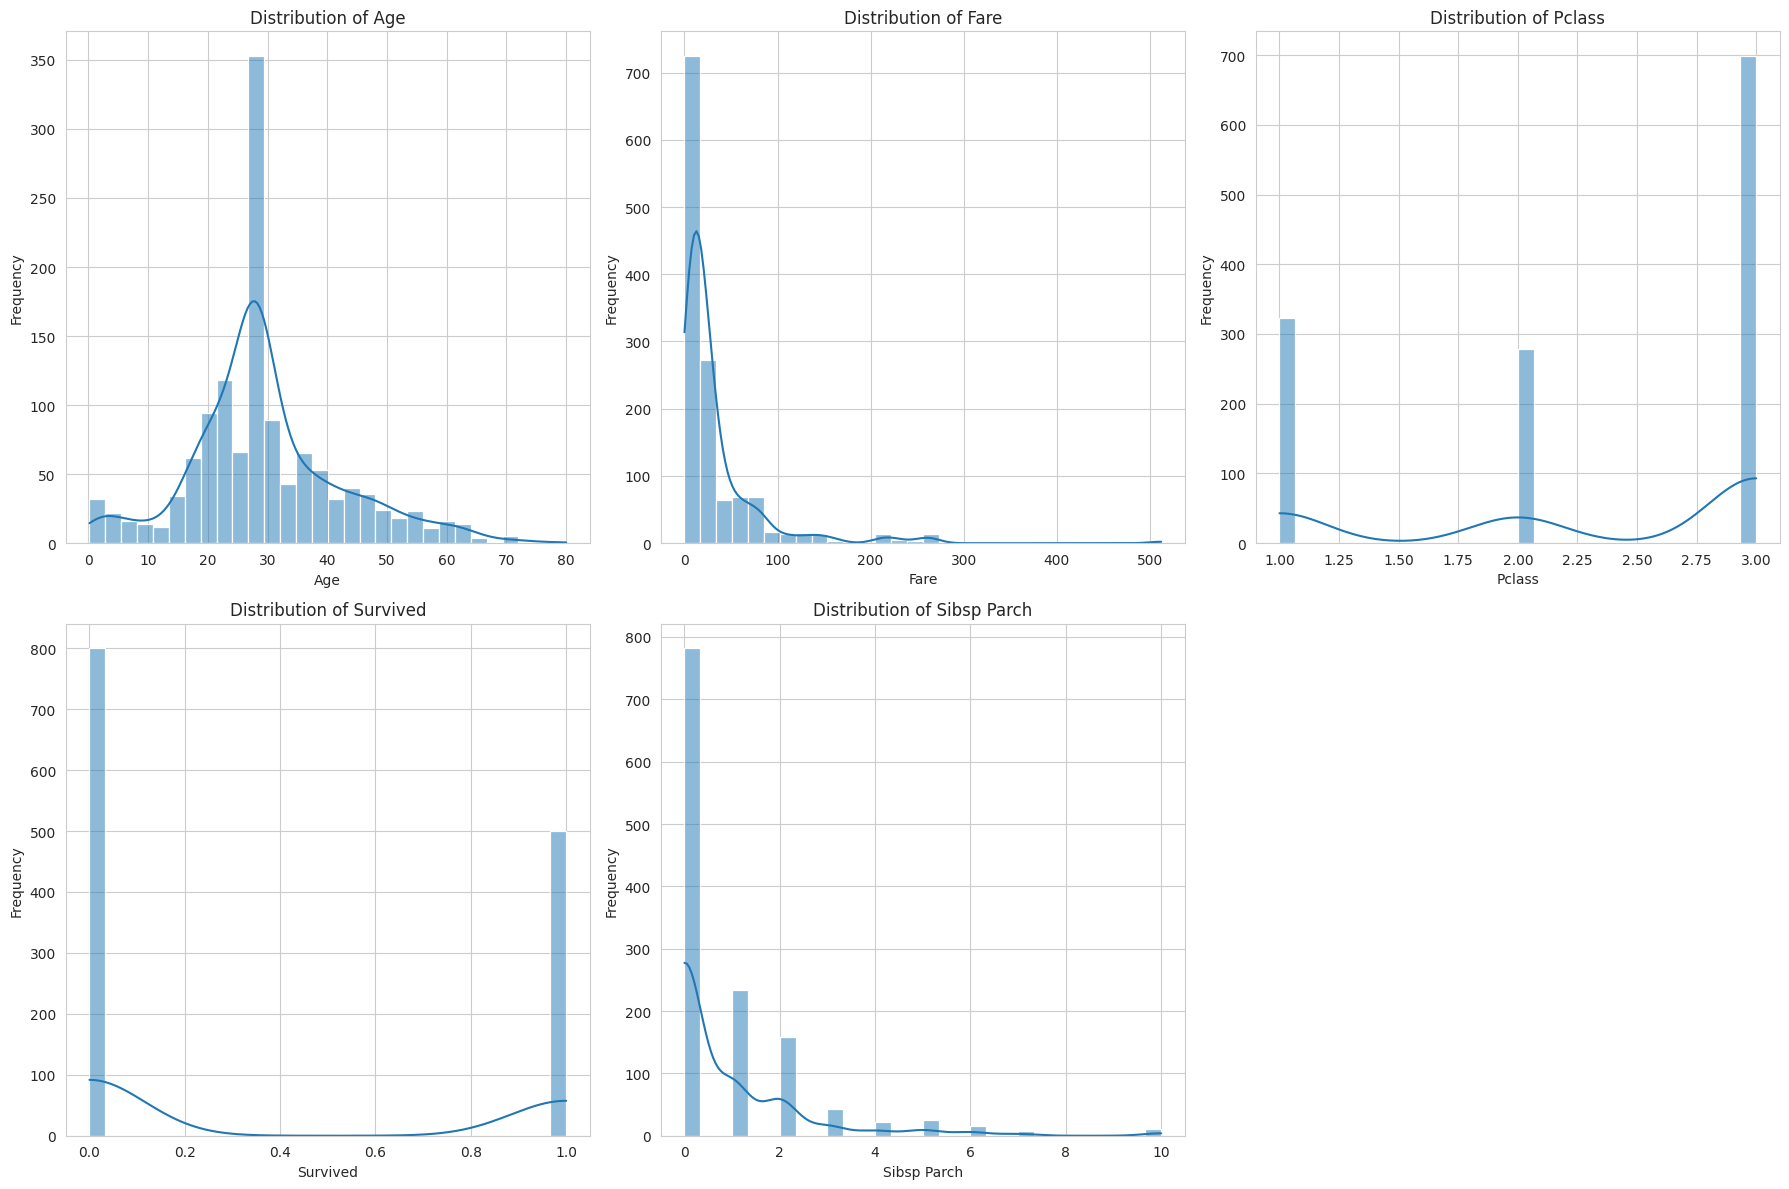

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set a style for the plots
sns.set_style('whitegrid')

print('--- Visualizing Numerical Feature Distributions ---')

# Numeric columns to visualize
numeric_cols = ['age', 'fare', 'pclass', 'survived', 'sibsp_parch']

plt.figure(figsize=(18, 12))
for i, col in enumerate(numeric_cols, 1):
    plt.subplot(2, 3, i) # Adjust subplot grid as needed
    sns.histplot(df[col], kde=True, bins=30)
    plt.title(f'Distribution of {col.replace('_', ' ').title()}')
    plt.xlabel(col.replace('_', ' ').title())
    plt.ylabel('Frequency')
plt.tight_layout()
plt.show()


--- Visualizing Categorical Feature Counts ---


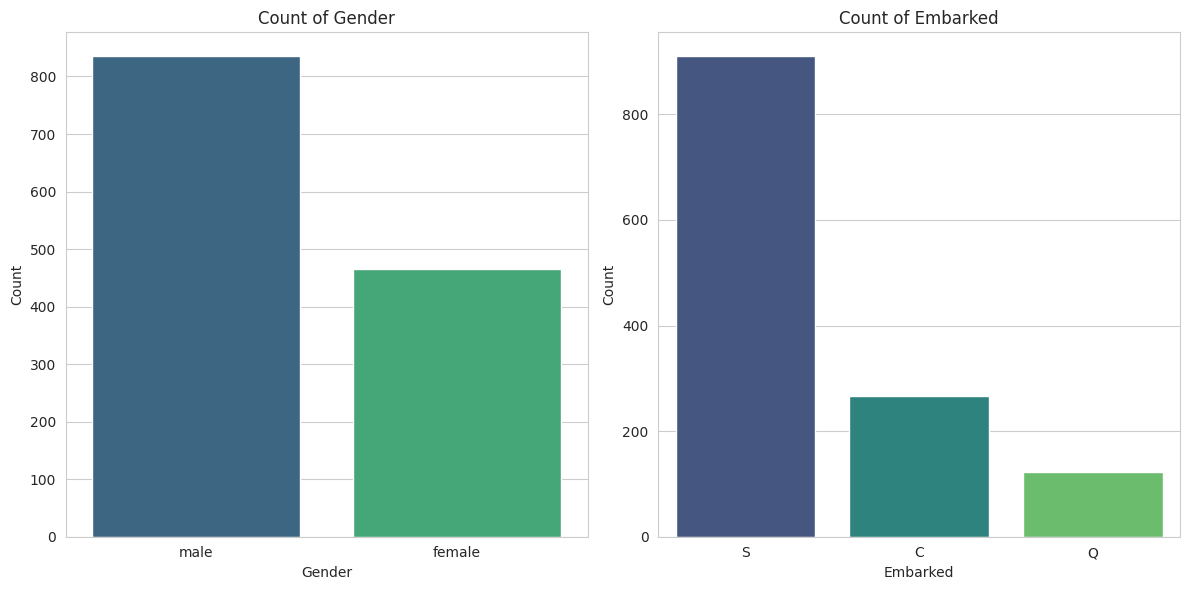

In [ ]:
print('\n--- Visualizing Categorical Feature Counts ---')

# Categorical columns to visualize
categorical_cols = ['gender', 'embarked']

plt.figure(figsize=(12, 6))
for i, col in enumerate(categorical_cols, 1):
    plt.subplot(1, 2, i)
    sns.countplot(x=df[col], palette='viridis', hue=df[col], legend=False)
    plt.title(f'Count of {col.title()}')
    plt.xlabel(col.title())
    plt.ylabel('Count')
plt.tight_layout()
plt.show()

In [ ]:
df = df.drop('name', axis=1)

print("--- DataFrame after dropping 'name' column ---")
display(df.head())

print("\n--- DataFrame Info after dropping 'name' column ---")
df.info()

--- DataFrame after dropping 'name' column ---


,passenger_id,pclass,survived,gender,age,sibsp_parch,fare,embarked,date
0,1,3,0,male,42.0,0.0,7.5500,S,1990-01-01
1,2,3,0,male,28.0,2.0,20.2500,S,1990-01-02
2,3,2,0,male,28.0,2.0,14.4542,S,1990-01-03
3,4,3,1,female,35.0,2.0,20.2500,S,1990-01-04
4,5,3,1,female,16.0,0.0,7.6500,S,1990-01-05



--- DataFrame Info after dropping 'name' column ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1300 entries, 0 to 1299
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   passenger_id  1300 non-null   object        
 1   pclass        1300 non-null   int64         
 2   survived      1300 non-null   int64         
 3   gender        1300 non-null   object        
 4   age           1300 non-null   float64       
 5   sibsp_parch   1300 non-null   float64       
 6   fare          1300 non-null   float64       
 7   embarked      1300 non-null   object        
 8   date          1300 non-null   datetime64[ns]
dtypes: datetime64[ns](1), float64(3), int64(2), object(3)
memory usage: 91.5+ KB


In [ ]:
print('\n--- Descriptive Statistics for Numerical Columns ---')
display(df.describe())
# Perform one-hot encoding on 'gender' and 'embarked'
df = pd.get_dummies(df, columns=['gender', 'embarked'], drop_first=True)

print("--- DataFrame after Encoding (First 5 rows) ---")
display(df.head())

print("\n--- Updated Column List ---")
print(df.columns.tolist())


--- Descriptive Statistics for Numerical Columns ---


,pclass,survived,age,sibsp_parch,fare,date
count,1300.000000,1300.000000,1300.000000,1300.000000,1300.000000,1300
mean,2.289231,0.384615,29.576862,0.889231,33.438250,1991-10-12 12:00:00
min,1.000000,0.000000,0.170000,0.000000,0.000000,1990-01-01 00:00:00
25%,2.000000,0.000000,22.000000,0.000000,7.895800,1990-11-21 18:00:00
50%,3.000000,0.000000,28.000000,0.000000,14.454200,1991-10-12 12:00:00
75%,3.000000,1.000000,35.000000,1.000000,31.275000,1992-09-01 06:00:00
max,3.000000,1.000000,80.000000,10.000000,512.329200,1993-07-23 00:00:00
std,0.838475,0.486691,12.885210,1.587589,51.883941,NaN


--- DataFrame after Encoding (First 5 rows) ---


,passenger_id,pclass,survived,age,sibsp_parch,fare,date,gender_male,embarked_Q,embarked_S
0,1,3,0,42.0,0.0,7.5500,1990-01-01,True,False,True
1,2,3,0,28.0,2.0,20.2500,1990-01-02,True,False,True
2,3,2,0,28.0,2.0,14.4542,1990-01-03,True,False,True
3,4,3,1,35.0,2.0,20.2500,1990-01-04,False,False,True
4,5,3,1,16.0,0.0,7.6500,1990-01-05,False,False,True



--- Updated Column List ---
['passenger_id', 'pclass', 'survived', 'age', 'sibsp_parch', 'fare', 'date', 'gender_male', 'embarked_Q', 'embarked_S']


--- Correlation Matrix ---


,pclass,survived,age,sibsp_parch,fare
pclass,1.000000,-0.308653,-0.375870,0.052424,-0.557679
survived,-0.308653,1.000000,-0.045268,0.024295,0.242529
age,-0.375870,-0.045268,1.000000,-0.192897,0.177234
sibsp_parch,0.052424,0.024295,-0.192897,1.000000,0.225185
fare,-0.557679,0.242529,0.177234,0.225185,1.000000


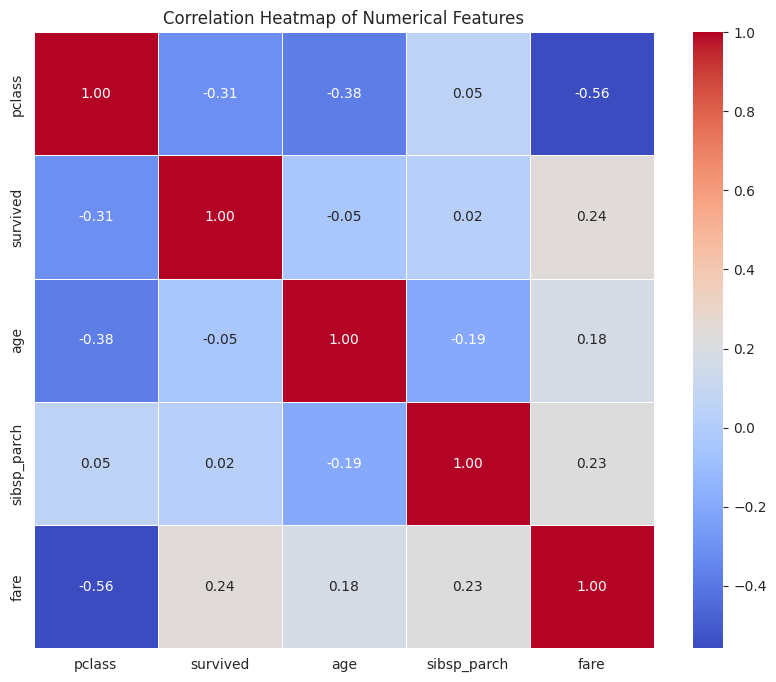

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Calculate the correlation matrix
# Note: passenger_id is likely not useful for correlation, so we'll focus on the others
corr_matrix = df.select_dtypes(include=['number']).corr()

print('--- Correlation Matrix ---')
display(corr_matrix)

# Visualize the correlation matrix using a heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap of Numerical Features')
plt.show()

--- Generating Scatter Plot Matrix (Pairplot) ---


<Figure size 1500x1000 with 0 Axes>

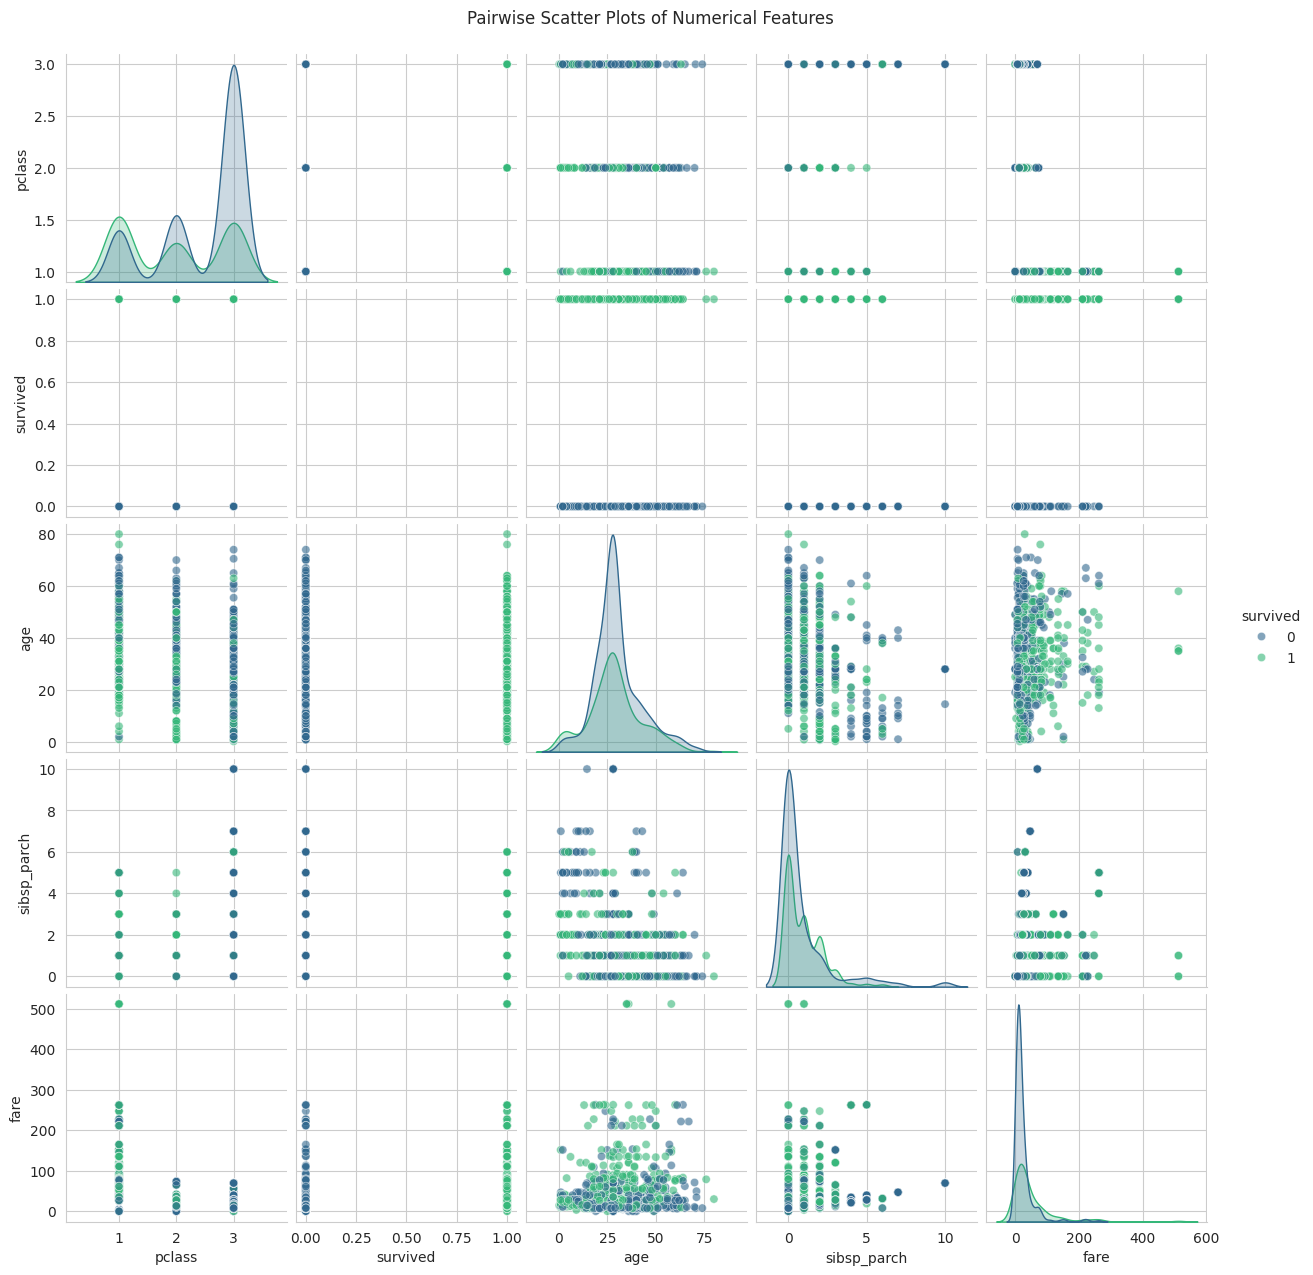

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Identifying numerical columns (excluding passenger_id as it is an identifier)
numeric_df = df.select_dtypes(include=['number']).drop(columns=['passenger_id'], errors='ignore')

print('--- Generating Scatter Plot Matrix (Pairplot) ---')

# Creating the pairplot
# We use 'survived' as hue to see if there are patterns related to survival
plt.figure(figsize=(15, 10))
sns.pairplot(df, vars=numeric_df.columns, hue='survived', palette='viridis', diag_kind='kde', plot_kws={'alpha': 0.6})
plt.suptitle('Pairwise Scatter Plots of Numerical Features', y=1.02)
plt.show()

In [ ]:
# List columns suitable for Logistic Regression
target = 'survived'
features = [col for col in df.columns if col not in [target, 'passenger_id', 'date']]

print(f"Target Variable: {target}")
print(f"Feature Candidates: {features}")

# Displaying descriptive stats for these specific features to confirm readiness
display(df[features].describe())

Target Variable: survived
Feature Candidates: ['pclass', 'age', 'sibsp_parch', 'fare', 'gender_male', 'embarked_Q', 'embarked_S']


,pclass,age,sibsp_parch,fare
count,1300.000000,1300.000000,1300.000000,1300.000000
mean,2.289231,29.576862,0.889231,33.438250
std,0.838475,12.885210,1.587589,51.883941
min,1.000000,0.170000,0.000000,0.000000
25%,2.000000,22.000000,0.000000,7.895800
50%,3.000000,28.000000,0.000000,14.454200
75%,3.000000,35.000000,1.000000,31.275000
max,3.000000,80.000000,10.000000,512.329200


In [ ]:
from sklearn.model_selection import train_test_split

# Define X (features) and y (target)
X = df[features]
y = df[target]

# Split the data (70% training, 30% testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

print(f"Training set shape: {X_train.shape}")
print(f"Testing set shape: {X_test.shape}")
print("\n--- First 5 rows of X_train ---")
display(X_train.head())

Training set shape: (910, 7)
Testing set shape: (390, 7)

--- First 5 rows of X_train ---


,pclass,age,sibsp_parch,fare,gender_male,embarked_Q,embarked_S
1148,1,62.00,0.0,26.5500,True,False,True
151,1,41.00,0.0,30.5000,True,False,True
1013,1,22.00,0.0,135.6333,True,False,False
318,3,30.00,0.0,9.5000,True,False,True
1008,2,0.83,2.0,18.7500,True,False,True


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

# Prepare data for single feature model
X_train_age = X_train[['age']]
X_test_age = X_test[['age']]

# Initialize and train the model
log_model_age = LogisticRegression()
log_model_age.fit(X_train_age, y_train)

# Make predictions
y_pred_age = log_model_age.predict(X_test_age)

# Evaluate the model
print(f'--- Logistic Regression Results (Feature: Age) ---')
print(f'Accuracy: {accuracy_score(y_test, y_pred_age):.4f}')
print('\nClassification Report:')
print(classification_report(y_test, y_pred_age))

--- Logistic Regression Results (Feature: Age) ---
Accuracy: 0.6154

Classification Report:
              precision    recall  f1-score   support

           0       0.62      1.00      0.76       240
           1       0.00      0.00      0.00       150

    accuracy                           0.62       390
   macro avg       0.31      0.50      0.38       390
weighted avg       0.38      0.62      0.47       390



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

# Prepare data for the multi-feature model
features_subset = ['fare', 'age']
X_train_subset = X_train[features_subset]
X_test_subset = X_test[features_subset]

# Initialize and train the model
log_model_multi = LogisticRegression()
log_model_multi.fit(X_train_subset, y_train)

# Make predictions
y_pred_multi = log_model_multi.predict(X_test_subset)

# Evaluate the model
print(f'--- Logistic Regression Results (Features: {features_subset}) ---')
print(f'Accuracy: {accuracy_score(y_test, y_pred_multi):.4f}')
print('\nClassification Report:')
print(classification_report(y_test, y_pred_multi))

--- Logistic Regression Results (Features: ['fare', 'age']) ---
Accuracy: 0.6410

Classification Report:
              precision    recall  f1-score   support

           0       0.65      0.90      0.76       240
           1       0.59      0.23      0.33       150

    accuracy                           0.64       390
   macro avg       0.62      0.56      0.54       390
weighted avg       0.63      0.64      0.59       390



In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

# Prepare data for the new model including pclass
features_pclass = ['pclass', 'fare', 'age']
X_train_pclass = X_train[features_pclass]
X_test_pclass = X_test[features_pclass]

# Initialize and train the model
log_model_pclass = LogisticRegression()
log_model_pclass.fit(X_train_pclass, y_train)

# Make predictions
y_pred_pclass = log_model_pclass.predict(X_test_pclass)

# Evaluate the model
print(f'--- Logistic Regression Results (Features: {features_pclass}) ---')
print(f'Accuracy: {accuracy_score(y_test, y_pred_pclass):.4f}')
print('\nClassification Report:')
print(classification_report(y_test, y_pred_pclass))

--- Logistic Regression Results (Features: ['pclass', 'fare', 'age']) ---
Accuracy: 0.6795

Classification Report:
              precision    recall  f1-score   support

           0       0.69      0.87      0.77       240
           1       0.64      0.37      0.47       150

    accuracy                           0.68       390
   macro avg       0.67      0.62      0.62       390
weighted avg       0.67      0.68      0.66       390



In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

# Prepare data for the model focusing on pclass
X_train_p = X_train[['pclass']]
X_test_p = X_test[['pclass']]

# Initialize and train the model
log_model_p = LogisticRegression()
log_model_p.fit(X_train_p, y_train)

# Make predictions
y_pred_p = log_model_p.predict(X_test_p)

# Evaluate the model
print(f'--- Logistic Regression Results (Feature: Pclass) ---')
print(f'Accuracy: {accuracy_score(y_test, y_pred_p):.4f}')
print('\nClassification Report:')
print(classification_report(y_test, y_pred_p))

--- Logistic Regression Results (Feature: Pclass) ---
Accuracy: 0.6744

Classification Report:
              precision    recall  f1-score   support

           0       0.69      0.85      0.76       240
           1       0.62      0.39      0.48       150

    accuracy                           0.67       390
   macro avg       0.66      0.62      0.62       390
weighted avg       0.66      0.67      0.65       390



In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

# Prepare data for the model focusing on gender_male
X_train_g = X_train[['gender_male']]
X_test_g = X_test[['gender_male']]

# Initialize and train the model
log_model_g = LogisticRegression()
log_model_g.fit(X_train_g, y_train)

# Make predictions
y_pred_g = log_model_g.predict(X_test_g)

# Evaluate the model
print(f'--- Logistic Regression Results (Feature: Gender_Male) ---')
print(f'Accuracy: {accuracy_score(y_test, y_pred_g):.4f}')
print('\nClassification Report:')
print(classification_report(y_test, y_pred_g))

--- Logistic Regression Results (Feature: Gender_Male) ---
Accuracy: 0.7718

Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.84      0.82       240
           1       0.72      0.66      0.69       150

    accuracy                           0.77       390
   macro avg       0.76      0.75      0.75       390
weighted avg       0.77      0.77      0.77       390



In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

# Prepare data for the model focusing on gender_male and embarked_Q
features_q = ['gender_male', 'embarked_Q']
X_train_q = X_train[features_q]
X_test_q = X_test[features_q]

# Initialize and train the model
log_model_q = LogisticRegression()
log_model_q.fit(X_train_q, y_train)

# Make predictions
y_pred_q = log_model_q.predict(X_test_q)

# Evaluate the model
print(f'--- Logistic Regression Results (Features: {features_q}) ---')
print(f'Accuracy: {accuracy_score(y_test, y_pred_q):.4f}')
print('\nClassification Report:')
print(classification_report(y_test, y_pred_q))

--- Logistic Regression Results (Features: ['gender_male', 'embarked_Q']) ---
Accuracy: 0.7718

Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.84      0.82       240
           1       0.72      0.66      0.69       150

    accuracy                           0.77       390
   macro avg       0.76      0.75      0.75       390
weighted avg       0.77      0.77      0.77       390



In [ ]:
import numpy as np
from sklearn.linear_model import LogisticRegression

# Define the features for this specific model
features_e = ['gender_male', 'embarked_Q', 'embarked_S']

# Prepare data for the new model
X_train_e = X_train[features_e]
X_test_e = X_test[features_e]

# Initialize and train the model
log_model_e = LogisticRegression()
log_model_e.fit(X_train_e, y_train)

# Get coefficients and intercept from the newly trained model
intercept = log_model_e.intercept_[0]
coeffs = log_model_e.coef_[0]
features_list = features_e # Use the actual features used for training

# Build the equation string for the log-odds (z)
equation = f"z = {intercept:.4f}"
for coef, feat in zip(coeffs, features_list):
    equation += f" + ({coef:.4f} * {feat})"

print("--- Logistic Regression Decision Equation (Log-Odds) ---")
print(equation)
print("\nWhere Probability(Survived) = 1 / (1 + e^-z)")

--- Logistic Regression Decision Equation (Log-Odds) ---
z = 1.6960 + (-2.4280 * gender_male) + (-1.0993 * embarked_Q) + (-0.8799 * embarked_S)

Where Probability(Survived) = 1 / (1 + e^-z)


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

# Prepare data for the model focusing on gender and all embarkation points
features_e = ['gender_male', 'embarked_Q', 'embarked_S']
X_train_e = X_train[features_e]
X_test_e = X_test[features_e]

# Initialize and train the model
log_model_e = LogisticRegression()
log_model_e.fit(X_train_e, y_train)

# Make predictions
y_pred_e = log_model_e.predict(X_test_e)

# Evaluate the model
print(f'--- Logistic Regression Results (Features: {features_e}) ---')
print(f'Accuracy: {accuracy_score(y_test, y_pred_e):.4f}')
print('\nClassification Report:')
print(classification_report(y_test, y_pred_e))

--- Logistic Regression Results (Features: ['gender_male', 'embarked_Q', 'embarked_S']) ---
Accuracy: 0.7718

Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.84      0.82       240
           1       0.72      0.66      0.69       150

    accuracy                           0.77       390
   macro avg       0.76      0.75      0.75       390
weighted avg       0.77      0.77      0.77       390



<Figure size 800x600 with 0 Axes>

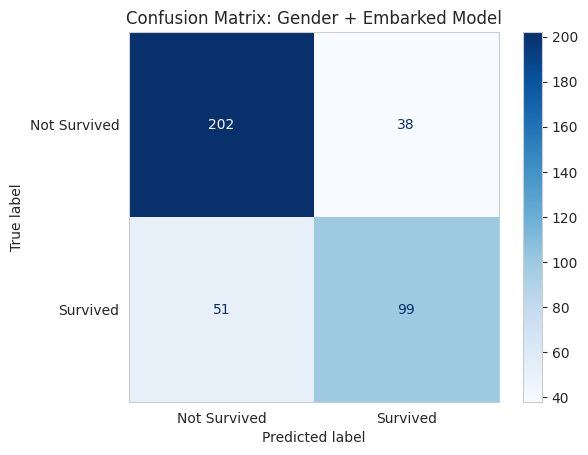


--- Confusion Matrix Breakdown ---
True Negatives (Correctly predicted death): 202
False Positives (Incorrectly predicted survival): 38
False Negatives (Incorrectly predicted death): 51
True Positives (Correctly predicted survival): 99


In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Calculate confusion matrix for the gender + embarked model
cm = confusion_matrix(y_test, y_pred_e)

# Plot the confusion matrix
plt.figure(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Not Survived', 'Survived'])
disp.plot(cmap='Blues', values_format='d')
plt.title('Confusion Matrix: Gender + Embarked Model')
plt.grid(False)
plt.show()

# Print detailed counts
tn, fp, fn, tp = cm.ravel()
print(f'\n--- Confusion Matrix Breakdown ---')
print(f'True Negatives (Correctly predicted death): {tn}')
print(f'False Positives (Incorrectly predicted survival): {fp}')
print(f'False Negatives (Incorrectly predicted death): {fn}')
print(f'True Positives (Correctly predicted survival): {tp}')

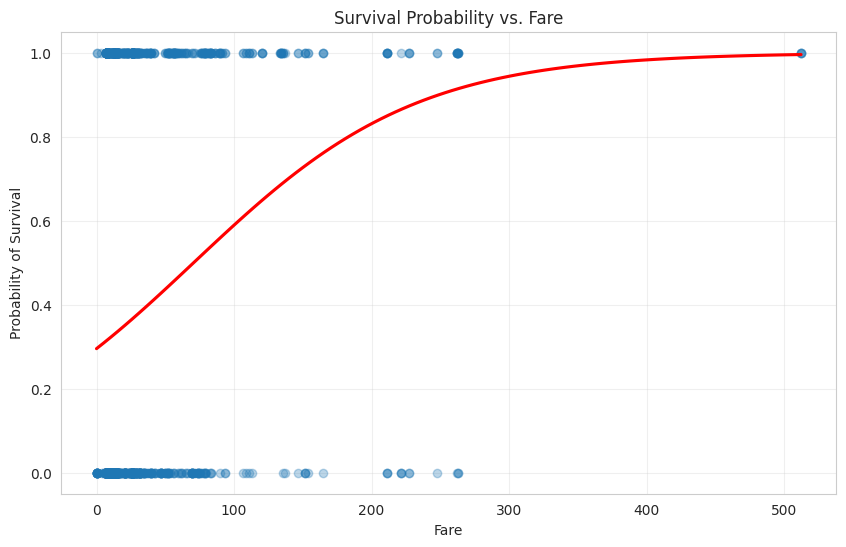

In [ ]:

import seaborn as sns
import matplotlib.pyplot as plt

# Visualize the survival probability vs fare using a logistic regression line
plt.figure(figsize=(10, 6))
sns.regplot(x='fare', y='survived', data=df, logistic=True, ci=None,
            scatter_kws={'alpha':0.3}, line_kws={'color':'red'})

plt.title('Survival Probability vs. Fare')
plt.xlabel('Fare')
plt.ylabel('Probability of Survival')
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import pandas as pd

# Selecting numerical features and target
# Note: passenger_id and date are excluded as they are identifiers/time-series
features_linear = ['pclass', 'age', 'sibsp_parch', 'fare', 'gender_male', 'embarked_Q', 'embarked_S']
target = 'survived'

X_lin = df[features_linear]
y_lin = df[target]

# Initialize and train the model
lin_model_full = LinearRegression()
lin_model_full.fit(X_lin, y_lin)

# Make predictions and evaluate
y_pred_lin_full = lin_model_full.predict(X_lin)
mse = mean_squared_error(y_lin, y_pred_lin_full)
r2 = r2_score(y_lin, y_pred_lin_full)

print('--- Linear Regression Results (All Numerical Features) ---')
print(f'Mean Squared Error: {mse:.4f}')
print(f'R-squared Score: {r2:.4f}')

# Display coefficients to understand feature impact
coeffs_df = pd.DataFrame({'Feature': features_linear, 'Coefficient': lin_model_full.coef_})
coeffs_df = coeffs_df.sort_values(by='Coefficient', ascending=False)
print('\n--- Model Coefficients ---')
display(coeffs_df)

--- Linear Regression Results (All Numerical Features) ---
Mean Squared Error: 0.1498
R-squared Score: 0.3673

--- Model Coefficients ---


,Feature,Coefficient
3,fare,0.000251
1,age,-0.005364
2,sibsp_parch,-0.025753
5,embarked_Q,-0.091392
6,embarked_S,-0.099320
0,pclass,-0.151699
4,gender_male,-0.500585


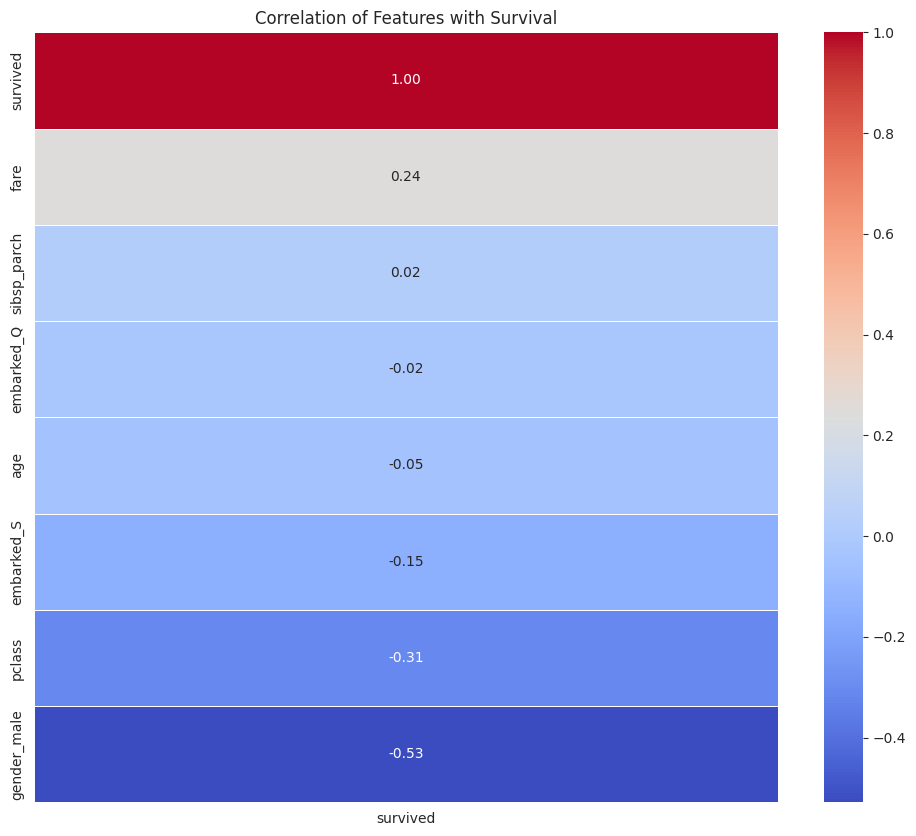

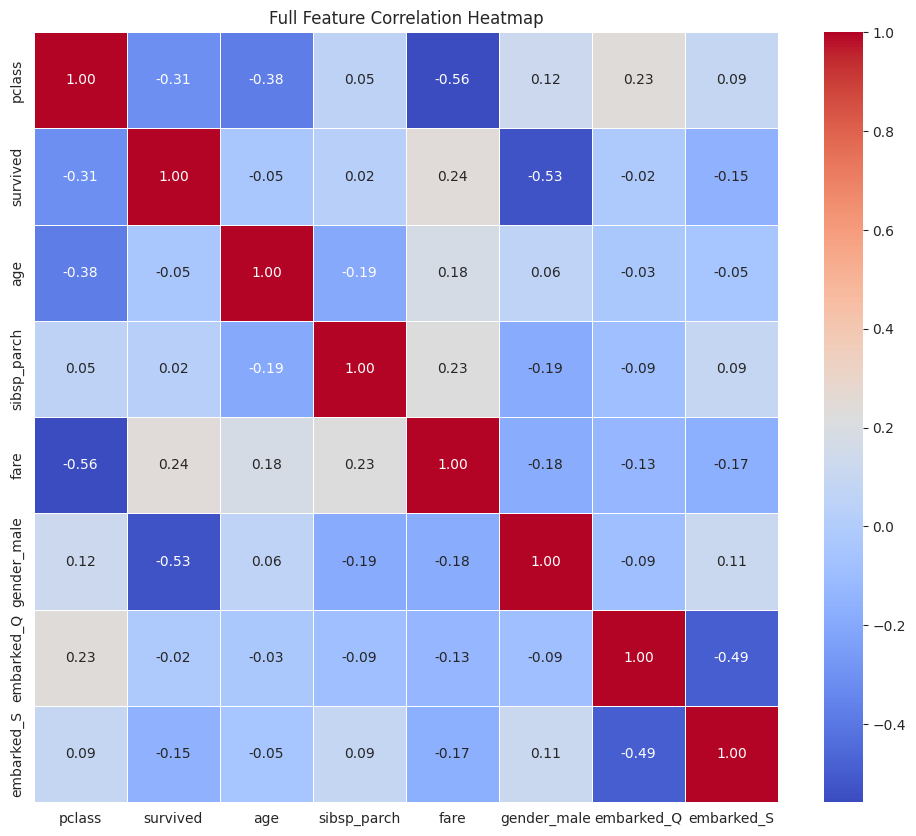

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Calculate the correlation matrix for numerical columns
# We include the encoded variables to see their relationship with survival
corr_matrix = df.select_dtypes(include=['number', 'bool']).corr()

# Filter to show correlations specifically with 'survived'
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix[['survived']].sort_values(by='survived', ascending=False),
            annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)

plt.title('Correlation of Features with Survival')
plt.show()

# Also show the full heatmap for context
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Full Feature Correlation Heatmap')
plt.show()

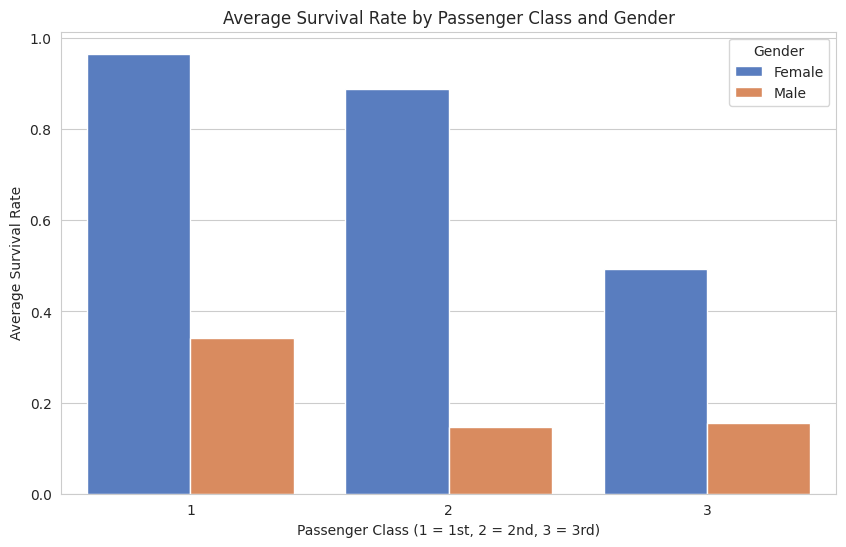

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Set the aesthetic style of the plots
sns.set_style('whitegrid')

plt.figure(figsize=(10, 6))

# Create a bar plot showing the mean of 'survived' for each 'pclass' and 'gender_male'
# We use 'errorbar=None' as 'ci' is deprecated in newer versions of Seaborn
sns.barplot(x='pclass', y='survived', hue='gender_male', data=df, palette='muted', errorbar=None)

plt.title('Average Survival Rate by Passenger Class and Gender')
plt.xlabel('Passenger Class (1 = 1st, 2 = 2nd, 3 = 3rd)')
plt.ylabel('Average Survival Rate')
plt.legend(title='Gender', labels=['Female', 'Male'])
plt.show()

In [ ]:
!pip install pyvis

In [ ]:
from sklearn.neural_network import MLPClassifier

# Define the MLP model architecture based on the visualization code's expectations
# (e.g., input features -> hidden_1 -> hidden_2 -> output)
# Using 'logistic' activation for demonstration as it's common in this context,
# but 'relu' is often a good default.
# Ensure hidden_1 and hidden_2 are defined from earlier in the cell or are available globally.
hidden_1 = 5 # As defined in the visualization code
hidden_2 = 2 # As defined in the visualization code
mlp = MLPClassifier(hidden_layer_sizes=(hidden_1, hidden_2), activation='relu', max_iter=1000, random_state=42)

# Train the MLP model using the training data
mlp.fit(X_train, y_train)

print("MLP Model Trained Successfully!")
print(f"Number of layers: {mlp.n_layers_}")
print(f"Output activation function: {mlp.out_activation_}")

from pyvis.network import Network
import numpy as np
import IPython

# 1. Sample 200 random instances for simulation context
X_sample = X_test.sample(200, random_state=42)

# 2. Initialize PyVis network
net = Network(height='700px', width='100%', notebook=True, directed=True, bgcolor='#222222', font_color='white')

# --- LAYERS & NODES ---
input_features = X_train.columns.tolist()

# Level 0: Inputs
for i, feat in enumerate(input_features):
    net.add_node(f'in_{i}', label=feat, color='#3498db', size=25, level=0, title=f'Input Feature: {feat}')

# Level 1: Hidden 1
for j in range(hidden_1):
    net.add_node(f'h1_{j}', label=f'N1_{j}', color='#e74c3c', size=20, level=1, title='Hidden Neuron Layer 1')

# Level 2: Hidden 2
for k in range(hidden_2):
    net.add_node(f'h2_{k}', label=f'N2_{k}', color='#f1c40f', size=15, level=2, title='Hidden Neuron Layer 2')

# Level 3: Output
net.add_node('out', label='SURVIVAL', color='#2ecc71', shape='star', size=30, level=3)

# --- EDGES (Weights as Flow) ---
# Input -> H1
w0 = mlp.coefs_[0]
for i in range(len(input_features)):
    for j in range(hidden_1):
        val = w0[i, j]
        net.add_edge(f'in_{i}', f'h1_{j}', value=abs(val)*5, color='#5dade2' if val > 0 else '#ec7063', title=f'Weight: {val:.4f}')

# H1 -> H2
w1 = mlp.coefs_[1]
for j in range(hidden_1):
    for k in range(hidden_2):
        val = w1[j, k]
        net.add_edge(f'h1_{j}', f'h2_{k}', value=abs(val)*5, color='#f4d03f')

# H2 -> Out
w2 = mlp.coefs_[2]
for k in range(hidden_2):
    val = w2[k, 0]
    net.add_edge(f'h2_{k}', 'out', value=abs(val)*5, color='#58d68d')

# --- LEGEND ---
net.add_node('L1', label='Blue: Input', color='#3498db', x=-500, y=-200, fixed=True, physics=False)
net.add_node('L2', label='Red: Layer 1', color='#e74c3c', x=-500, y=-150, fixed=True, physics=False)
net.add_node('L3', label='Yellow: Layer 2', color='#f1c40f', x=-500, y=-100, fixed=True, physics=False)
net.add_node('L4', label='Green: Output', color='#2ecc71', x=-500, y=-50, fixed=True, physics=False)

# --- OPTIONS (Interactive Physics & LR Flow) ---
net.set_options("""
var options = {
  "layout": {
    "hierarchical": {
      "enabled": true,
      "direction": "LR",
      "sortMethod": "directed"
    }
  },
  "physics": {
    "enabled": true,
    "barnesHut": {"gravitationalConstant": -2000, "centralGravity": 0.3, "springLength": 95},
    "stabilization": {"iterations": 100}
  },
  "interaction": {"hover": true, "navigationButtons": true},
  "configure": {
    "enabled": true,
    "filter": ["physics"]
  }
}
""")

# Save the file
net.show('interactive_mlp.html')

# Fix the HTML to use remote CDN resources manually since cdn_resources arg failed
with open('interactive_mlp.html', 'r') as f:
    html_content = f.read()

# Replace local path with remote CDN path
html_content = html_content.replace('lib/vis-network/standalone/umd/vis-network.min.js', 'https://unpkg.com/vis-network/standalone/umd/vis-network.min.js')

with open('interactive_mlp.html', 'w') as f:
    f.write(html_content)

IPython.display.HTML(filename='interactive_mlp.html')

MLP Model Trained Successfully!
Number of layers: 4
Output activation function: logistic
interactive_mlp.html


Resampled dataset shape (Undersampling): Counter({0: 350, 1: 350})
Resampled dataset shape (SMOTE): Counter({0: 560, 1: 560})


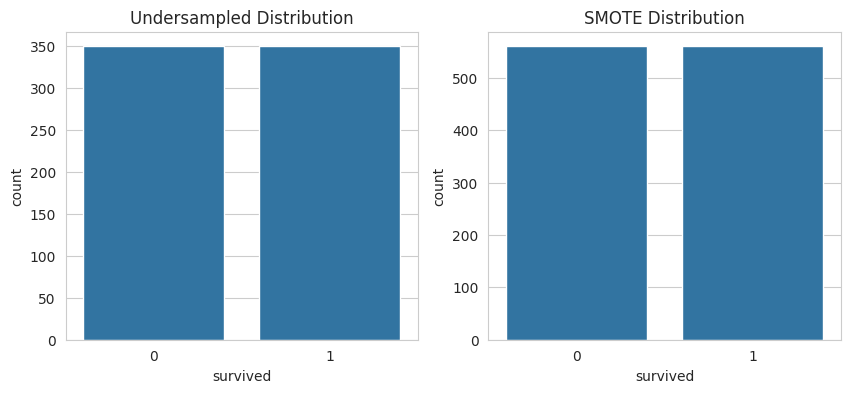

In [ ]:
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from collections import Counter

# 1. Random Undersampling
rus = RandomUnderSampler(random_state=42)
X_resampled_under, y_resampled_under = rus.fit_resample(X_train, y_train)
print('Resampled dataset shape (Undersampling):', Counter(y_resampled_under))

# 2. SMOTE Oversampling
smote = SMOTE(random_state=42)
X_resampled_smote, y_resampled_smote = smote.fit_resample(X_train, y_train)
print('Resampled dataset shape (SMOTE):', Counter(y_resampled_smote))

# Visualizing the distribution change
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
sns.countplot(x=y_resampled_under)
plt.title('Undersampled Distribution')

plt.subplot(1, 2, 2)
sns.countplot(x=y_resampled_smote)
plt.title('SMOTE Distribution')
plt.show()

In [ ]:
import numpy as np
from sklearn.utils import resample

# Parameters
n_iterations = 1000
bootstrap_stats = []

# Use the best performing features found previously: gender and embarkation points
features_boot = ['gender_male', 'embarked_Q', 'embarked_S']

print(f'Running {n_iterations} bootstrap iterations...')

for i in range(n_iterations):
    # Prepare bootstrap sample (resample with replacement)
    X_bs, y_bs = resample(X_train[features_boot], y_train, random_state=i)

    # Train model
    model_bs = LogisticRegression()
    model_bs.fit(X_bs, y_bs)

    # Evaluate on the original held-out test set
    predictions = model_bs.predict(X_test[features_boot])
    score = accuracy_score(y_test, predictions)
    bootstrap_stats.append(score)

# Calculate Confidence Intervals (95%)
alpha = 0.95
p = ((1.0 - alpha) / 2.0) * 100
lower = max(0.0, np.percentile(bootstrap_stats, p))

p = (alpha + (1.0 - alpha) / 2.0) * 100
upper = min(1.0, np.percentile(bootstrap_stats, p))

print(f'\n95% Confidence Interval for Accuracy: [{lower:.4f}, {upper:.4f}]')
print(f'Mean Bootstrap Accuracy: {np.mean(bootstrap_stats):.4f}')

Running 1000 bootstrap iterations...

95% Confidence Interval for Accuracy: [0.7718, 0.7718]
Mean Bootstrap Accuracy: 0.7718


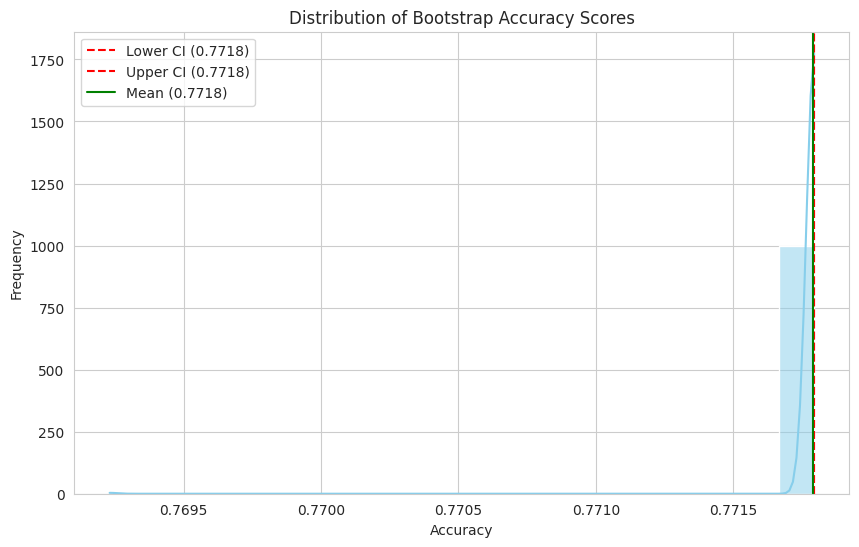

In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(bootstrap_stats, kde=True, color='skyblue', bins=20)

# Add CI lines
plt.axvline(lower, color='red', linestyle='--', label=f'Lower CI ({lower:.4f})')
plt.axvline(upper, color='red', linestyle='--', label=f'Upper CI ({upper:.4f})')
plt.axvline(np.mean(bootstrap_stats), color='green', linestyle='-', label=f'Mean ({np.mean(bootstrap_stats):.4f})')

plt.title('Distribution of Bootstrap Accuracy Scores')
plt.xlabel('Accuracy')
plt.ylabel('Frequency')
plt.legend()
plt.show()

In [ ]:
from sklearn.ensemble import RandomForestClassifier

# Initialize the Random Forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, max_depth=10)

# Train the model using all features (X_train contains 'pclass', 'age', 'sibsp_parch', 'fare', 'gender_male', 'embarked_Q', 'embarked_S')
rf_model.fit(X_train, y_train)

# Make predictions
y_pred_rf = rf_model.predict(X_test)

# Evaluate
rf_accuracy = accuracy_score(y_test, y_pred_rf)
print(f'--- Random Forest Results ---')
print(f'Accuracy: {rf_accuracy:.4f}')
print('\nClassification Report:')
print(classification_report(y_test, y_pred_rf))

--- Random Forest Results ---
Accuracy: 0.8179

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.89      0.86       240
           1       0.80      0.70      0.75       150

    accuracy                           0.82       390
   macro avg       0.81      0.80      0.80       390
weighted avg       0.82      0.82      0.82       390



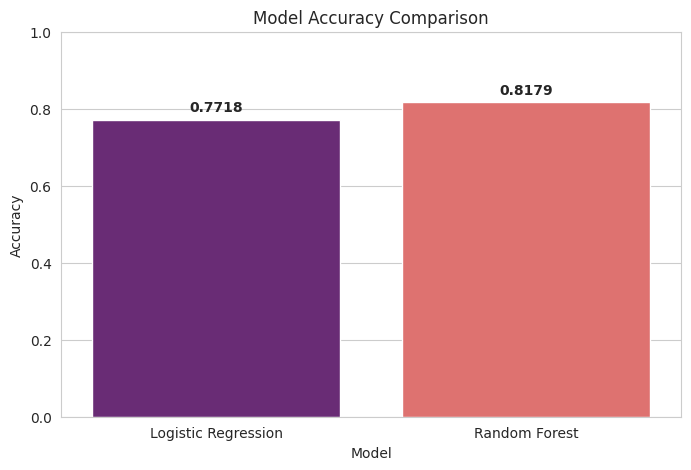

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Define and train the Logistic Regression model for comparison
features_e = ['gender_male', 'embarked_Q', 'embarked_S']
X_train_e = X_train[features_e]
X_test_e = X_test[features_e]

log_model_e = LogisticRegression()
log_model_e.fit(X_train_e, y_train)
y_pred_e = log_model_e.predict(X_test_e)

# Comparing Logistic Regression (Gender + Embarked) vs Random Forest
log_acc = accuracy_score(y_test, y_pred_e)

comparison_df = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest'],
    'Accuracy': [log_acc, rf_accuracy]
})

plt.figure(figsize=(8, 5))
sns.barplot(x='Model', y='Accuracy', data=comparison_df, palette='magma', hue='Model', legend=False)
plt.ylim(0, 1.0)
plt.title('Model Accuracy Comparison')
for i, val in enumerate(comparison_df['Accuracy']):
    plt.text(i, val + 0.02, f'{val:.4f}', ha='center', fontweight='bold')
plt.show()

In [ ]:
from sklearn.neural_network import MLPClassifier

# Define the MLP model architecture based on the visualization code's expectations
# (e.g., input features -> hidden_1 -> hidden_2 -> output)
# Using 'logistic' activation for demonstration as it's common in this context,
# but 'relu' is often a good default.
mlp = MLPClassifier(hidden_layer_sizes=(hidden_1, hidden_2), activation='relu', max_iter=1000, random_state=42)

# Train the MLP model using the training data
mlp.fit(X_train, y_train)

print("MLP Model Trained Successfully!")
print(f"Number of layers: {mlp.n_layers_}")
print(f"Output activation function: {mlp.out_activation_}")

MLP Model Trained Successfully!
Number of layers: 4
Output activation function: logistic


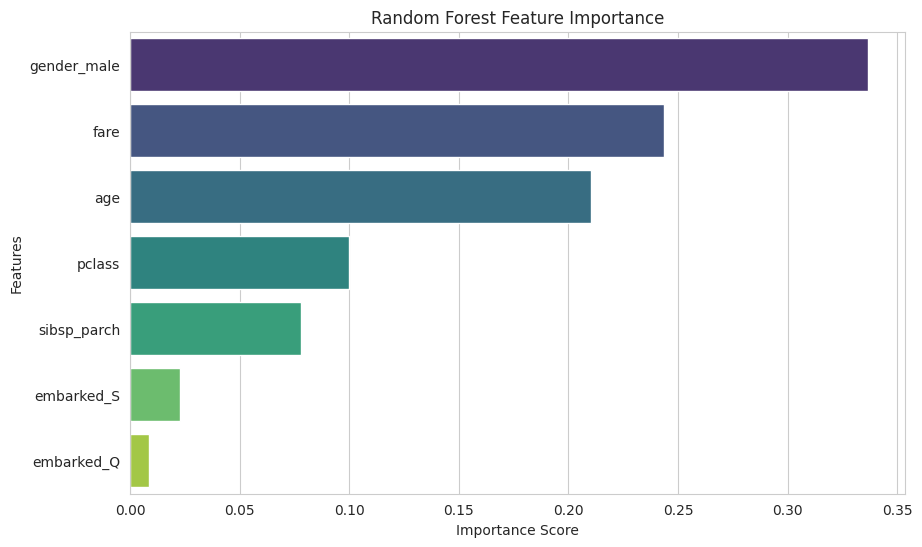

--- Feature Importance Scores ---


,Feature,Importance
4,gender_male,0.336740
3,fare,0.243805
1,age,0.210403
0,pclass,0.099775
2,sibsp_parch,0.077861
6,embarked_S,0.022599
5,embarked_Q,0.008817


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Get feature importances
importances = rf_model.feature_importances_
feature_names = X_train.columns

# Create a DataFrame for visualization
feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# Visualize
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='viridis', hue='Feature', legend=False)
plt.title('Random Forest Feature Importance')
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.show()

print("--- Feature Importance Scores ---")
display(feature_importance_df)

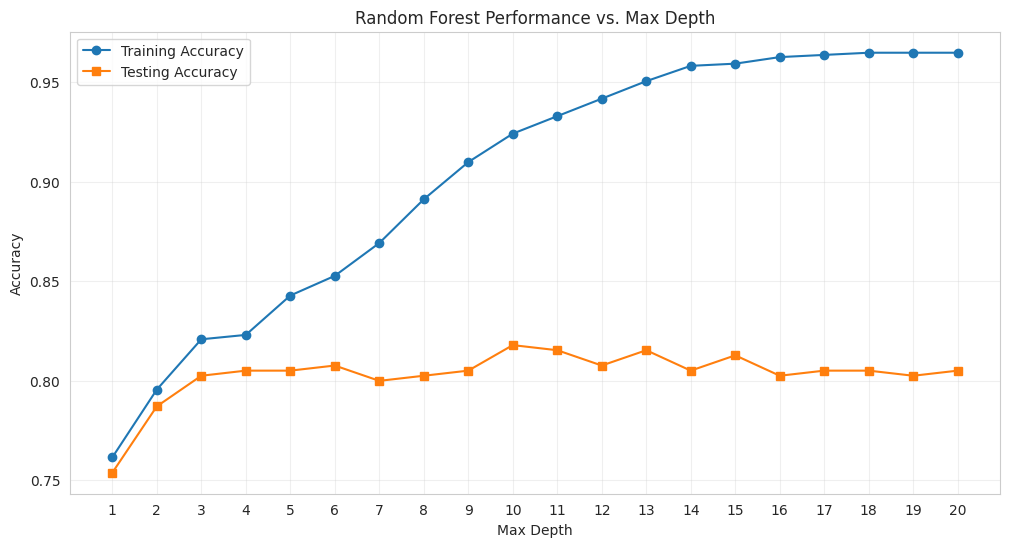

Best Max Depth: 10 with Testing Accuracy: 0.8179


In [ ]:
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

depths = range(1, 21)
train_accuracies = []
test_accuracies = []

for d in depths:
    # Initialize and train model with specific depth
    rf = RandomForestClassifier(n_estimators=100, max_depth=d, random_state=42)
    rf.fit(X_train, y_train)

    # Record training accuracy
    train_acc = accuracy_score(y_train, rf.predict(X_train))
    train_accuracies.append(train_acc)

    # Record testing accuracy
    test_acc = accuracy_score(y_test, rf.predict(X_test))
    test_accuracies.append(test_acc)

# Visualize the results
plt.figure(figsize=(12, 6))
plt.plot(depths, train_accuracies, label='Training Accuracy', marker='o')
plt.plot(depths, test_accuracies, label='Testing Accuracy', marker='s')
plt.title('Random Forest Performance vs. Max Depth')
plt.xlabel('Max Depth')
plt.ylabel('Accuracy')
plt.xticks(depths)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Find the best depth for the test set
best_depth = depths[np.argmax(test_accuracies)]
max_test_acc = max(test_accuracies)
print(f"Best Max Depth: {best_depth} with Testing Accuracy: {max_test_acc:.4f}")

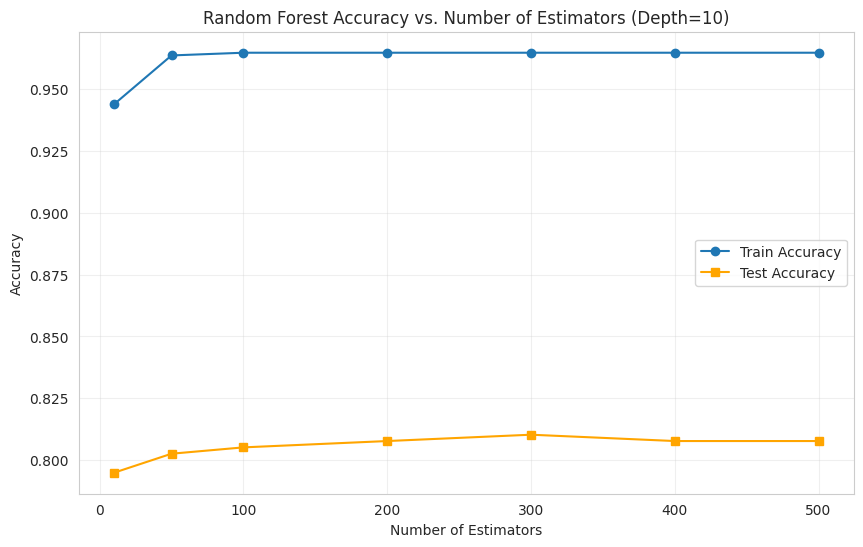

Best n_estimators: 300 with Test Accuracy: 0.8103


In [ ]:
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier

# Define the range of estimators to test
estimator_range = [10, 50, 100, 200, 300, 400, 500]
train_scores = []
test_scores = []

for n in estimator_range:
    # Initialize and train with current n_estimators and best_depth=10
    rf = RandomForestClassifier(n_estimators=n, max_depth=20, random_state=42, n_jobs=-1)
    rf.fit(X_train, y_train)

    train_scores.append(rf.score(X_train, y_train))
    test_scores.append(rf.score(X_test, y_test))

# Visualize the effect of n_estimators
plt.figure(figsize=(10, 6))
plt.plot(estimator_range, train_scores, label='Train Accuracy', marker='o')
plt.plot(estimator_range, test_scores, label='Test Accuracy', marker='s', color='orange')
plt.title('Random Forest Accuracy vs. Number of Estimators (Depth=10)')
plt.xlabel('Number of Estimators')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Output the best result
best_n = estimator_range[np.argmax(test_scores)]
print(f'Best n_estimators: {best_n} with Test Accuracy: {max(test_scores):.4f}')

Random Forest ROC-AUC Score: 0.8650


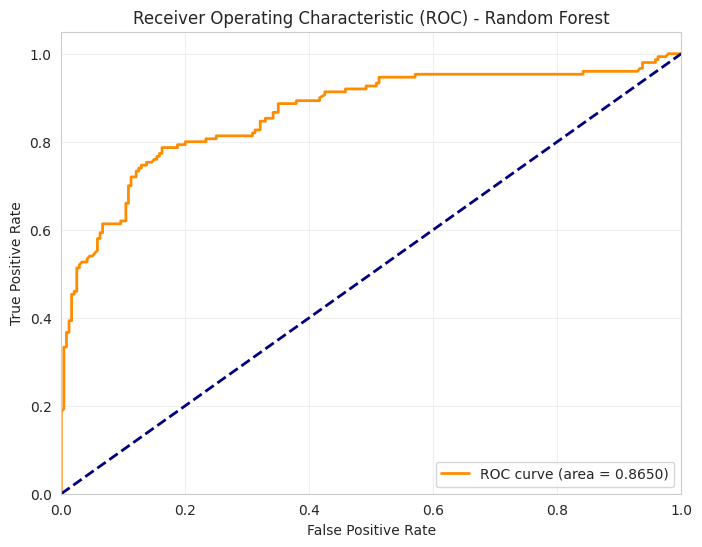

In [ ]:
from sklearn.metrics import roc_auc_score, roc_curve, auc
import matplotlib.pyplot as plt

# Get predicted probabilities for the positive class (survived = 1)
y_pred_proba_rf = final_rf_model.predict_proba(X_test)[:, 1]

# Calculate ROC-AUC score
rf_roc_auc = roc_auc_score(y_test, y_pred_proba_rf)
print(f'Random Forest ROC-AUC Score: {rf_roc_auc:.4f}')

# Generate ROC curve data
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba_rf)
roc_auc_val = auc(fpr, tpr)

# Plot ROC Curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc_val:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) - Random Forest')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.show()

--- Decision Tree Results ---
Accuracy: 0.8077

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.87      0.85       240
           1       0.77      0.71      0.74       150

    accuracy                           0.81       390
   macro avg       0.80      0.79      0.79       390
weighted avg       0.81      0.81      0.81       390



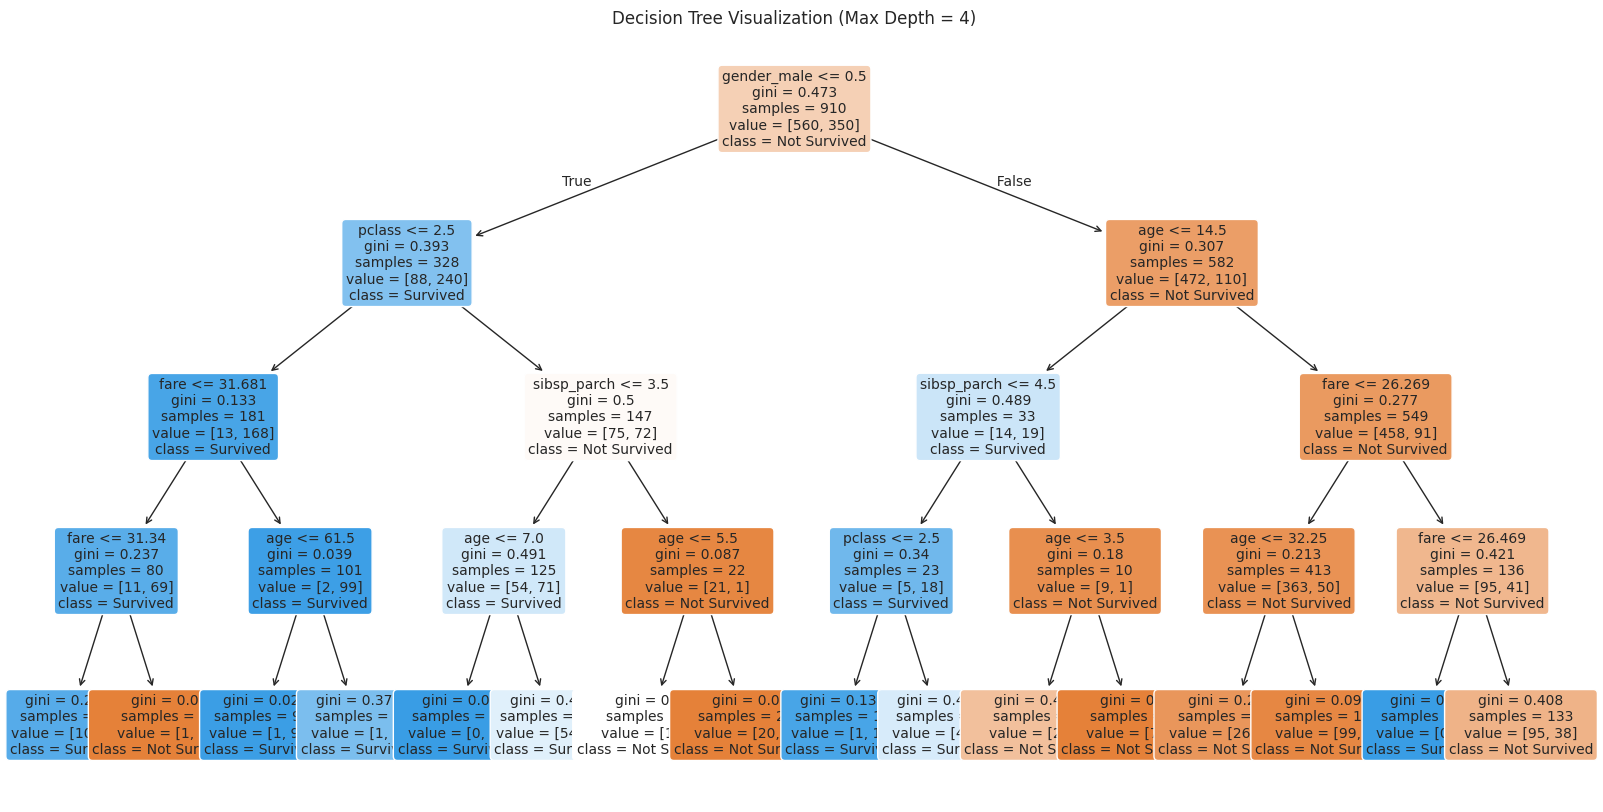

In [ ]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report
import matplotlib.pyplot as plt

# Initialize and train the Decision Tree
dt_model = DecisionTreeClassifier(max_depth=4, random_state=42)
dt_model.fit(X_train, y_train)

# Make predictions
y_pred_dt = dt_model.predict(X_test)

# Evaluate the model
dt_accuracy = accuracy_score(y_test, y_pred_dt)
print(f'--- Decision Tree Results ---')
print(f'Accuracy: {dt_accuracy:.4f}')
print('\nClassification Report:')
print(classification_report(y_test, y_pred_dt))

# Visualize the tree structure
plt.figure(figsize=(20, 10))
plot_tree(dt_model, feature_names=X_train.columns.tolist(), class_names=['Not Survived', 'Survived'], filled=True, rounded=True, fontsize=10)
plt.title('Decision Tree Visualization (Max Depth = 4)')
plt.show()

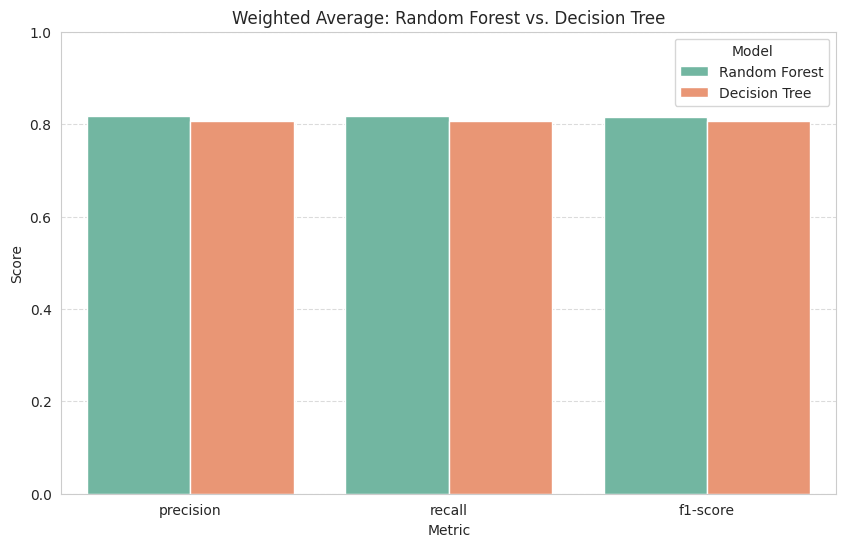

--- Random Forest Weighted Metrics ---
precision    0.816744
recall       0.817949
f1-score     0.815260
dtype: float64

--- Decision Tree Weighted Metrics ---
precision    0.806031
recall       0.807692
f1-score     0.806187
dtype: float64


In [ ]:
from sklearn.metrics import classification_report
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Generate reports as dictionaries
rf_report = classification_report(y_test, y_pred_rf, output_dict=True)
dt_report = classification_report(y_test, y_pred_dt, output_dict=True)

# Extract metrics for comparison
metrics = ['precision', 'recall', 'f1-score']
comparison_data = []

for model_name, report in [('Random Forest', rf_report), ('Decision Tree', dt_report)]:
    for metric in metrics:
        comparison_data.append({
            'Model': model_name,
            'Metric': metric,
            'Score': report['weighted avg'][metric]
        })

comparison_df = pd.DataFrame(comparison_data)

# Plotting
plt.figure(figsize=(10, 6))
sns.barplot(x='Metric', y='Score', hue='Model', data=comparison_df, palette='Set2')
plt.title('Weighted Average: Random Forest vs. Decision Tree')
plt.ylim(0, 1.0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

print("--- Random Forest Weighted Metrics ---")
print(pd.Series(rf_report['weighted avg']).drop('support'))

print("\n--- Decision Tree Weighted Metrics ---")
print(pd.Series(dt_report['weighted avg']).drop('support'))

In [ ]:
from sklearn.model_selection import GridSearchCV

# Define the parameter grid
param_grid = {
    'max_depth': [2, 4, 6, 8, 10, 12, 15],
    'min_samples_split': [2, 5, 10, 20],
    'criterion': ['gini', 'entropy']
}

# Initialize the Decision Tree Classifier
dt_base = DecisionTreeClassifier(random_state=42)

# Initialize GridSearchCV
grid_search = GridSearchCV(estimator=dt_base, param_grid=param_grid, cv=5, scoring='accuracy', n_jobs=-1)

# Fit the grid search to the training data
grid_search.fit(X_train, y_train)

# Extract the best parameters and score
best_params = grid_search.best_params_
best_score = grid_search.best_score_

print(f'--- GridSearchCV Results ---')
print(f'Best Parameters: {best_params}')
print(f'Best Cross-Validation Accuracy: {best_score:.4f}')

# Evaluate the best model on the test set
best_dt_model = grid_search.best_estimator_
y_pred_best_dt = best_dt_model.predict(X_test)
test_accuracy = accuracy_score(y_test, y_pred_best_dt)

print(f'Test Set Accuracy with Best Parameters: {test_accuracy:.4f}')
print('\nFinal Classification Report:')
print(classification_report(y_test, y_pred_best_dt))

--- GridSearchCV Results ---
Best Parameters: {'criterion': 'entropy', 'max_depth': 10, 'min_samples_split': 10}
Best Cross-Validation Accuracy: 0.7967
Test Set Accuracy with Best Parameters: 0.8077

Final Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.90      0.85       240
           1       0.80      0.66      0.73       150

    accuracy                           0.81       390
   macro avg       0.81      0.78      0.79       390
weighted avg       0.81      0.81      0.80       390



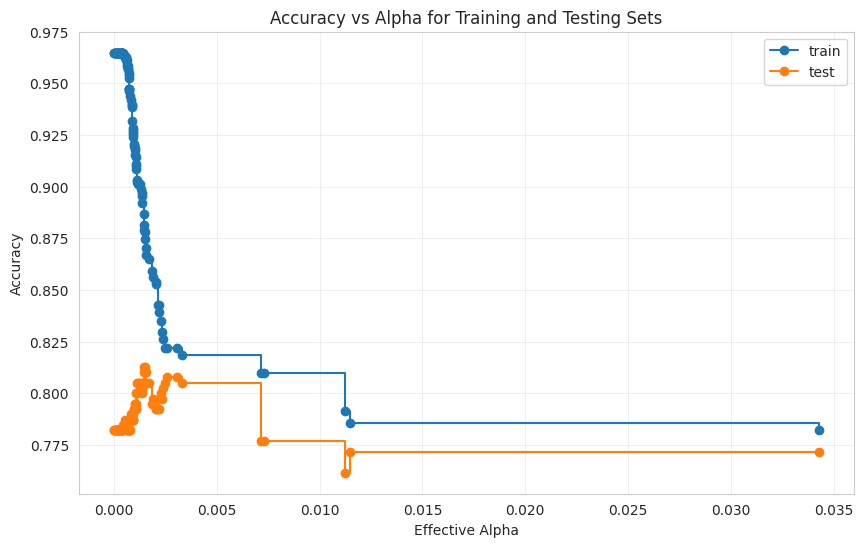

Optimal ccp_alpha: 0.001467
Pruned Tree Test Accuracy: 0.8128


In [ ]:
import matplotlib.pyplot as plt

# Compute the cost-complexity pruning path
clf = DecisionTreeClassifier(random_state=42)
path = clf.cost_complexity_pruning_path(X_train, y_train)
ccp_alphas, impurities = path.ccp_alphas, path.impurities

# Train a series of trees with different alphas
clfs = []
for ccp_alpha in ccp_alphas:
    clf = DecisionTreeClassifier(random_state=42, ccp_alpha=ccp_alpha)
    clf.fit(X_train, y_train)
    clfs.append(clf)

# Calculate scores for training and test sets
train_scores = [clf.score(X_train, y_train) for clf in clfs]
test_scores = [clf.score(X_test, y_test) for clf in clfs]

# Plot accuracy vs alpha
plt.figure(figsize=(10, 6))
plt.plot(ccp_alphas[:-1], train_scores[:-1], marker='o', label='train', drawstyle='steps-post')
plt.plot(ccp_alphas[:-1], test_scores[:-1], marker='o', label='test', drawstyle='steps-post')
plt.xlabel('Effective Alpha')
plt.ylabel('Accuracy')
plt.title('Accuracy vs Alpha for Training and Testing Sets')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Find the best alpha
best_alpha_idx = np.argmax(test_scores)
optimal_alpha = ccp_alphas[best_alpha_idx]
print(f'Optimal ccp_alpha: {optimal_alpha:.6f}')

# Final Pruned Tree
pruned_dt = DecisionTreeClassifier(random_state=42, ccp_alpha=optimal_alpha)
pruned_dt.fit(X_train, y_train)
print(f'Pruned Tree Test Accuracy: {pruned_dt.score(X_test, y_test):.4f}')

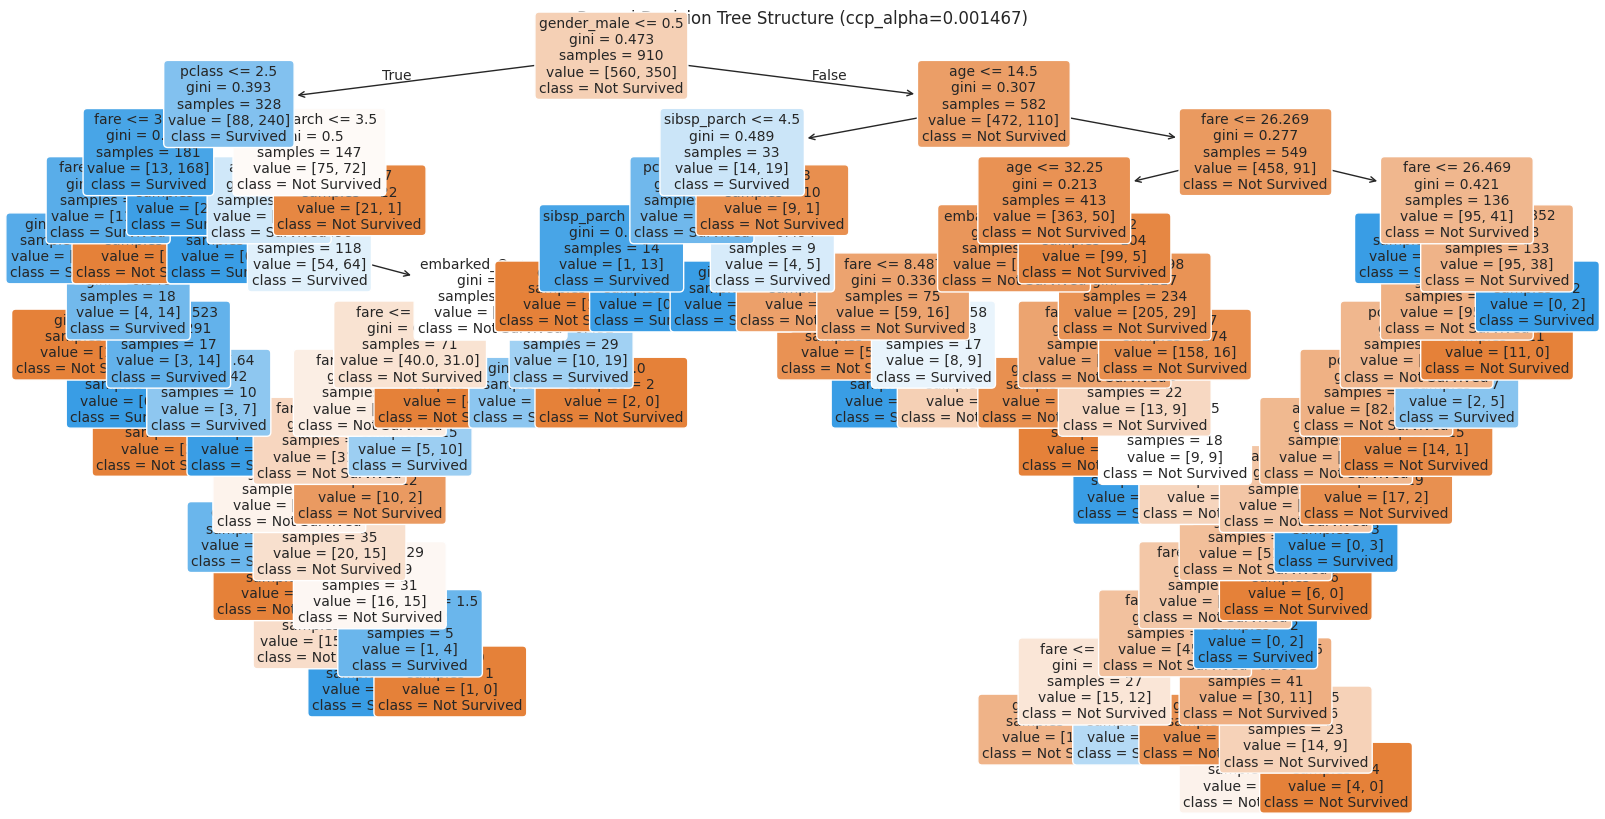

In [ ]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

# Visualize the pruned tree structure
plt.figure(figsize=(20, 10))
plot_tree(pruned_dt,
          feature_names=X_train.columns.tolist(),
          class_names=['Not Survived', 'Survived'],
          filled=True,
          rounded=True,
          fontsize=10)

plt.title(f'Pruned Decision Tree Structure (ccp_alpha={optimal_alpha:.6f})')
plt.show()

--- Final Model Performance Comparison ---


,Accuracy,Precision,Recall,F1-Score
Model,,,,
Logistic Regression (Gender+Emb),0.771795,0.722628,0.660000,0.689895
Random Forest (Optimized),0.817949,0.801527,0.700000,0.747331
Pruned Decision Tree,0.812821,0.808000,0.673333,0.734545


/tmp/ipykernel_503/3113401303.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=final_comparison_df.index, y='Accuracy', data=final_comparison_df.reset_index(), palette='viridis')


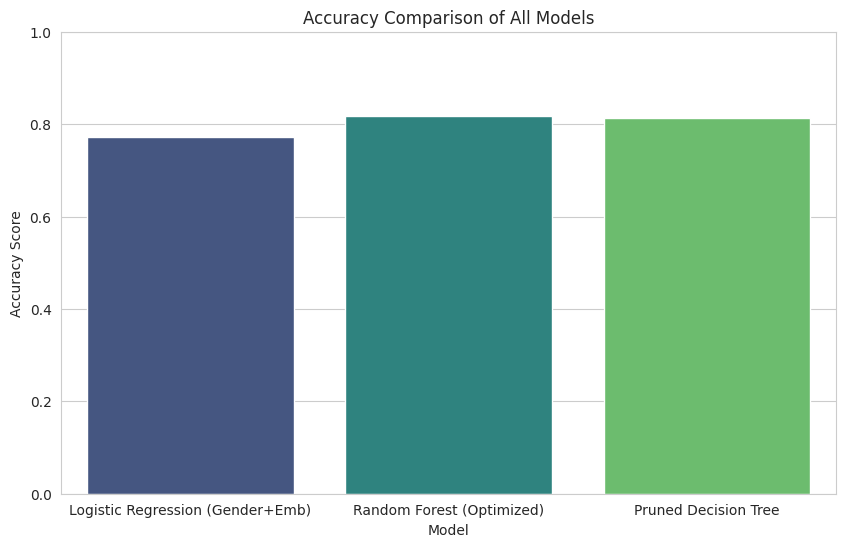

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import pandas as pd

# Define the models and their predictions
models = {
    'Logistic Regression (Gender+Emb)': y_pred_e,
    'Random Forest (Optimized)': y_pred_rf,
    'Pruned Decision Tree': pruned_dt.predict(X_test)
}

comparison_list = []

for name, preds in models.items():
    comparison_list.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, preds),
        'Precision': precision_score(y_test, preds),
        'Recall': recall_score(y_test, preds),
        'F1-Score': f1_score(y_test, preds)
    })

# Create Comparison DataFrame
final_comparison_df = pd.DataFrame(comparison_list).set_index('Model')

print("--- Final Model Performance Comparison ---")
display(final_comparison_df)

# Visualize Accuracy Comparison
plt.figure(figsize=(10, 6))
sns.barplot(x=final_comparison_df.index, y='Accuracy', data=final_comparison_df.reset_index(), palette='viridis')
plt.title('Accuracy Comparison of All Models')
plt.ylim(0, 1.0)
plt.ylabel('Accuracy Score')
plt.show()

In [ ]:
# Find the model with the maximum accuracy
best_model_name = final_comparison_df['Accuracy'].idxmax()
best_model_accuracy = final_comparison_df['Accuracy'].max()

print(f'--- Best Model Selection ---')
print(f'The best performing model is: {best_model_name}')
print(f'Accuracy: {best_model_accuracy:.4f}')

# Storing the best model object for future use
if best_model_name == 'Random Forest (Optimized)':
    best_model_object = final_rf_model
elif best_model_name == 'Pruned Decision Tree':
    best_model_object = pruned_dt
else:
    best_model_object = log_model_e

print(f'Model object has been assigned to "best_model_object".')

--- Best Model Selection ---
The best performing model is: Random Forest (Optimized)
Accuracy: 0.8179
Model object has been assigned to "best_model_object".


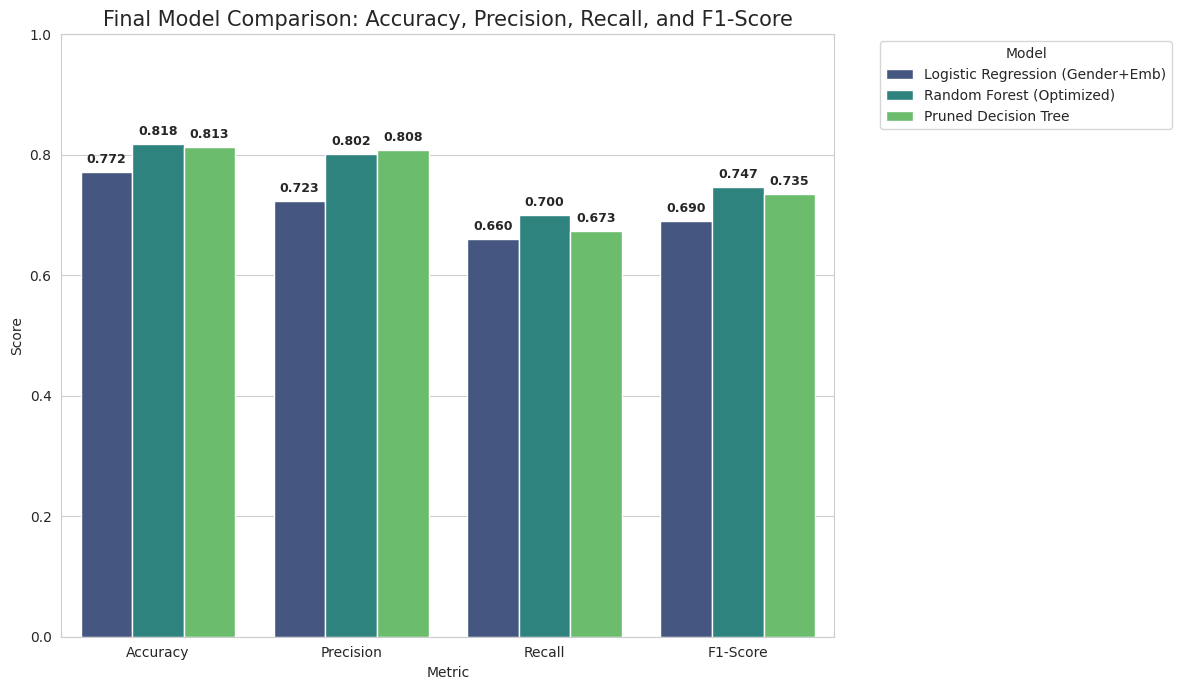

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Melting the dataframe to make it suitable for a grouped bar chart
comparison_melted = final_comparison_df.reset_index().melt(id_vars='Model', var_name='Metric', value_name='Score')

plt.figure(figsize=(12, 7))
sns.set_style('whitegrid')

# Creating the grouped bar chart
ax = sns.barplot(x='Metric', y='Score', hue='Model', data=comparison_melted, palette='viridis')

plt.title('Final Model Comparison: Accuracy, Precision, Recall, and F1-Score', fontsize=15)
plt.ylim(0, 1.0)
plt.ylabel('Score')
plt.xlabel('Metric')
plt.legend(title='Model', bbox_to_anchor=(1.05, 1), loc='upper left')

# Adding score labels on top of the bars
for p in ax.patches:
    if p.get_height() > 0:
        ax.annotate(format(p.get_height(), '.3f'),
                   (p.get_x() + p.get_width() / 2., p.get_height()),
                   ha = 'center', va = 'center',
                   xytext = (0, 9),
                   textcoords = 'offset points',
                   fontsize=9,
                   fontweight='bold')

plt.tight_layout()
plt.show()

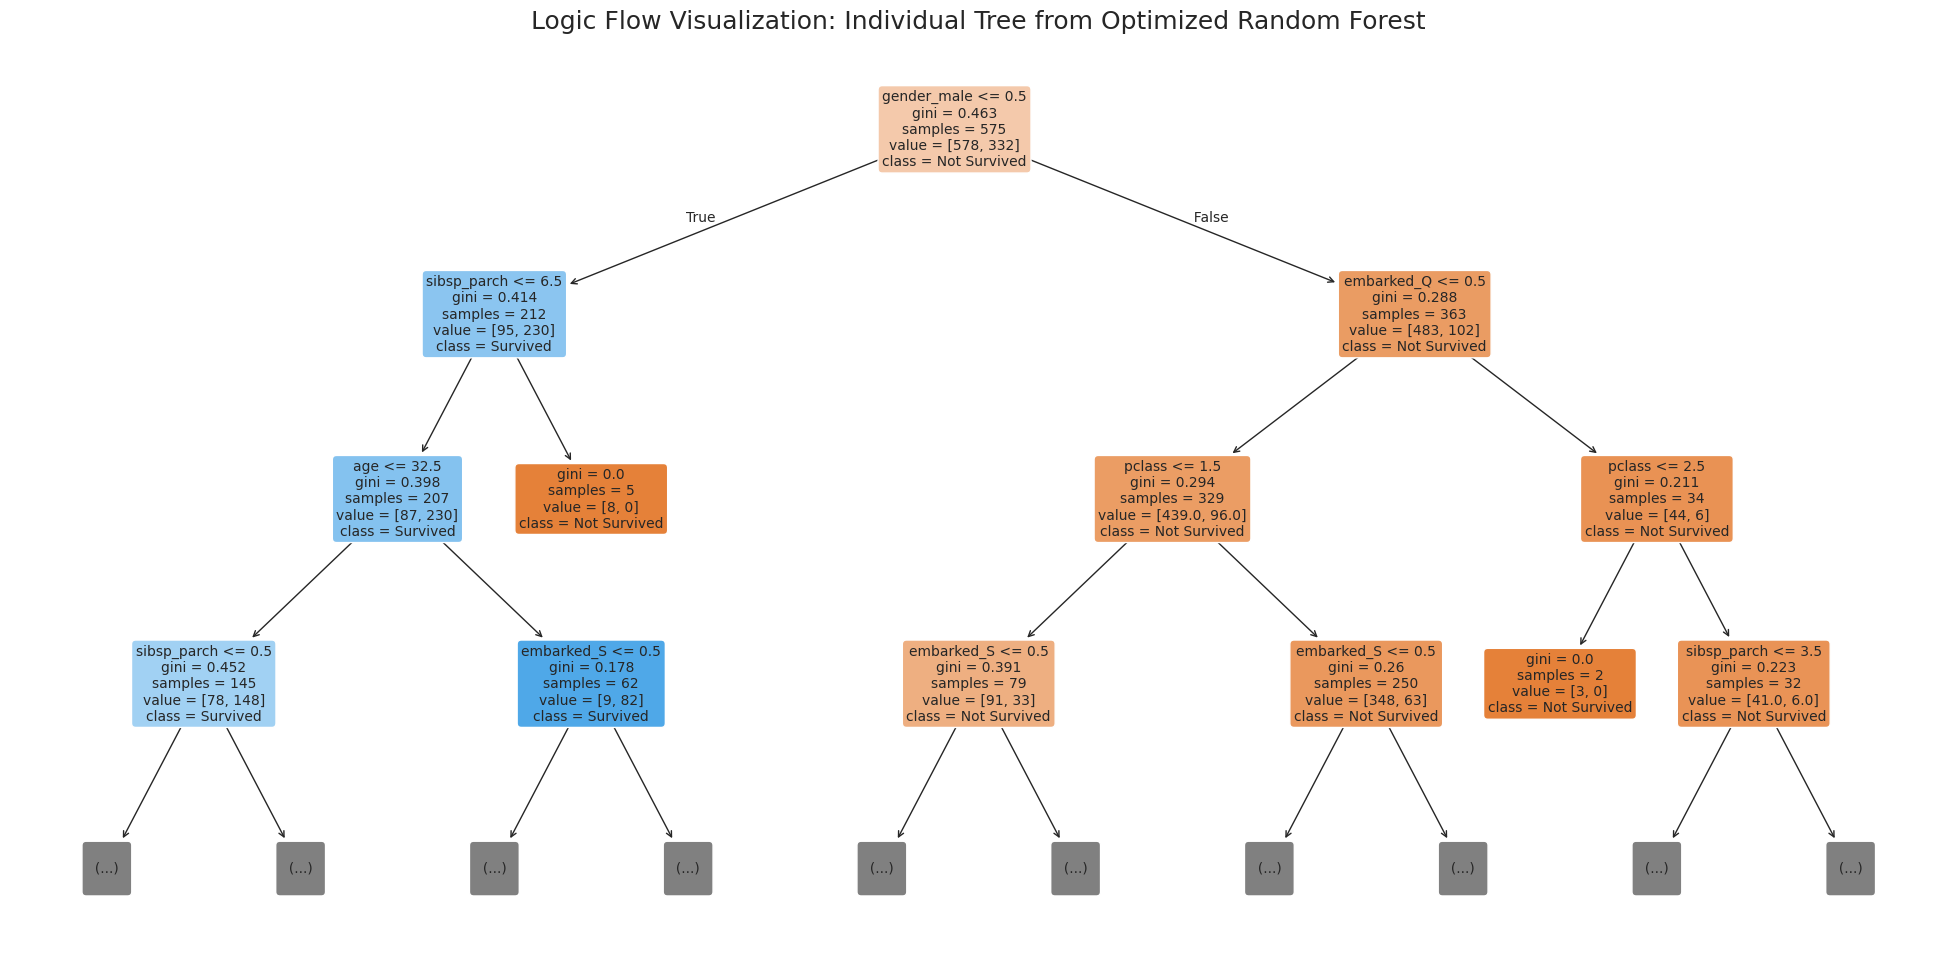

In [ ]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

# The Random Forest is an ensemble of trees.
# We can visualize the 'flow' of the first tree (estimator) to understand the logic.
plt.figure(figsize=(25, 12))

# Selecting the first tree from the forest
# We limit the depth for the visualization to keep the 'flow' readable
plot_tree(best_model_object.estimators_[0],
          feature_names=X_train.columns.tolist(),
          class_names=['Not Survived', 'Survived'],
          filled=True,
          rounded=True,
          fontsize=10,
          max_depth=3)

plt.title('Logic Flow Visualization: Individual Tree from Optimized Random Forest', fontsize=18)
plt.show()

In [ ]:
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score

# Initialize a simple Neural Network (MLP)
# We use a small architecture so we can 'see' the flow of weights
mlp = MLPClassifier(hidden_layer_sizes=(5, 2), max_iter=1000, random_state=42)

# Train on our standard features
mlp.fit(X_train, y_train)

# Evaluate
nn_preds = mlp.predict(X_test)
print(f'Neural Network Accuracy: {accuracy_score(y_test, nn_preds):.4f}')

Neural Network Accuracy: 0.6333


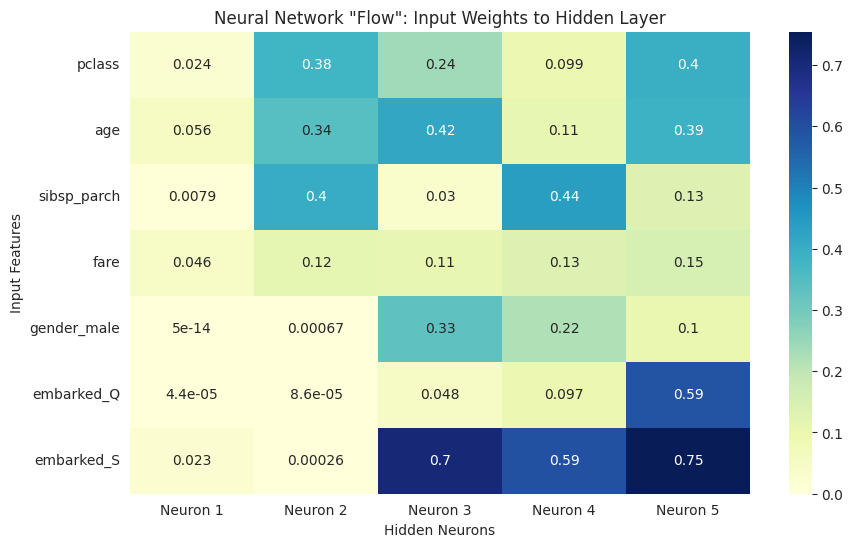

In [ ]:
import numpy as np

# Visualizing the 'Flow' of Feature Importance through the first layer weights
plt.figure(figsize=(10, 6))
weights = np.abs(mlp.coefs_[0]) # Absolute weights of the input layer
sns.heatmap(weights, annot=True, cmap='YlGnBu',
            yticklabels=X_train.columns,
            xticklabels=[f'Neuron {i+1}' for i in range(5)])

plt.title('Neural Network "Flow": Input Weights to Hidden Layer')
plt.ylabel('Input Features')
plt.xlabel('Hidden Neurons')
plt.show()

In [ ]:
import polars as pl

# Convert the pandas final_comparison_df to a Polars DataFrame
# We reset the index to include 'Model' as a column
pl_df = pl.from_pandas(final_comparison_df.reset_index())

print("--- Model Performance Analysis using Polars ---")
display(pl_df)

# Perform a study: Find the average performance across all models
avg_metrics = pl_df.select([
    pl.col("Accuracy").mean().alias("Avg_Accuracy"),
    pl.col("Precision").mean().alias("Avg_Precision"),
    pl.col("Recall").mean().alias("Avg_Recall"),
    pl.col("F1-Score").mean().alias("Avg_F1")
])

print("\n--- Average Metrics Across All Models ---")
display(avg_metrics)

# Identify models that have Accuracy above 80%
high_accuracy_models = pl_df.filter(pl.col("Accuracy") > 0.80)

print("\n--- Models with >80% Accuracy ---")
display(high_accuracy_models)

--- Model Performance Analysis using Polars ---


Model,Accuracy,Precision,Recall,F1-Score
str,f64,f64,f64,f64
"""Logistic Regression (Gender+Em…",0.771795,0.722628,0.66,0.689895
"""Random Forest (Optimized)""",0.817949,0.801527,0.7,0.747331
"""Pruned Decision Tree""",0.812821,0.808,0.673333,0.734545



--- Average Metrics Across All Models ---


Avg_Accuracy,Avg_Precision,Avg_Recall,Avg_F1
f64,f64,f64,f64
0.800855,0.777385,0.677778,0.723924



--- Models with >80% Accuracy ---


Model,Accuracy,Precision,Recall,F1-Score
str,f64,f64,f64,f64
"""Random Forest (Optimized)""",0.817949,0.801527,0.7,0.747331
"""Pruned Decision Tree""",0.812821,0.808,0.673333,0.734545


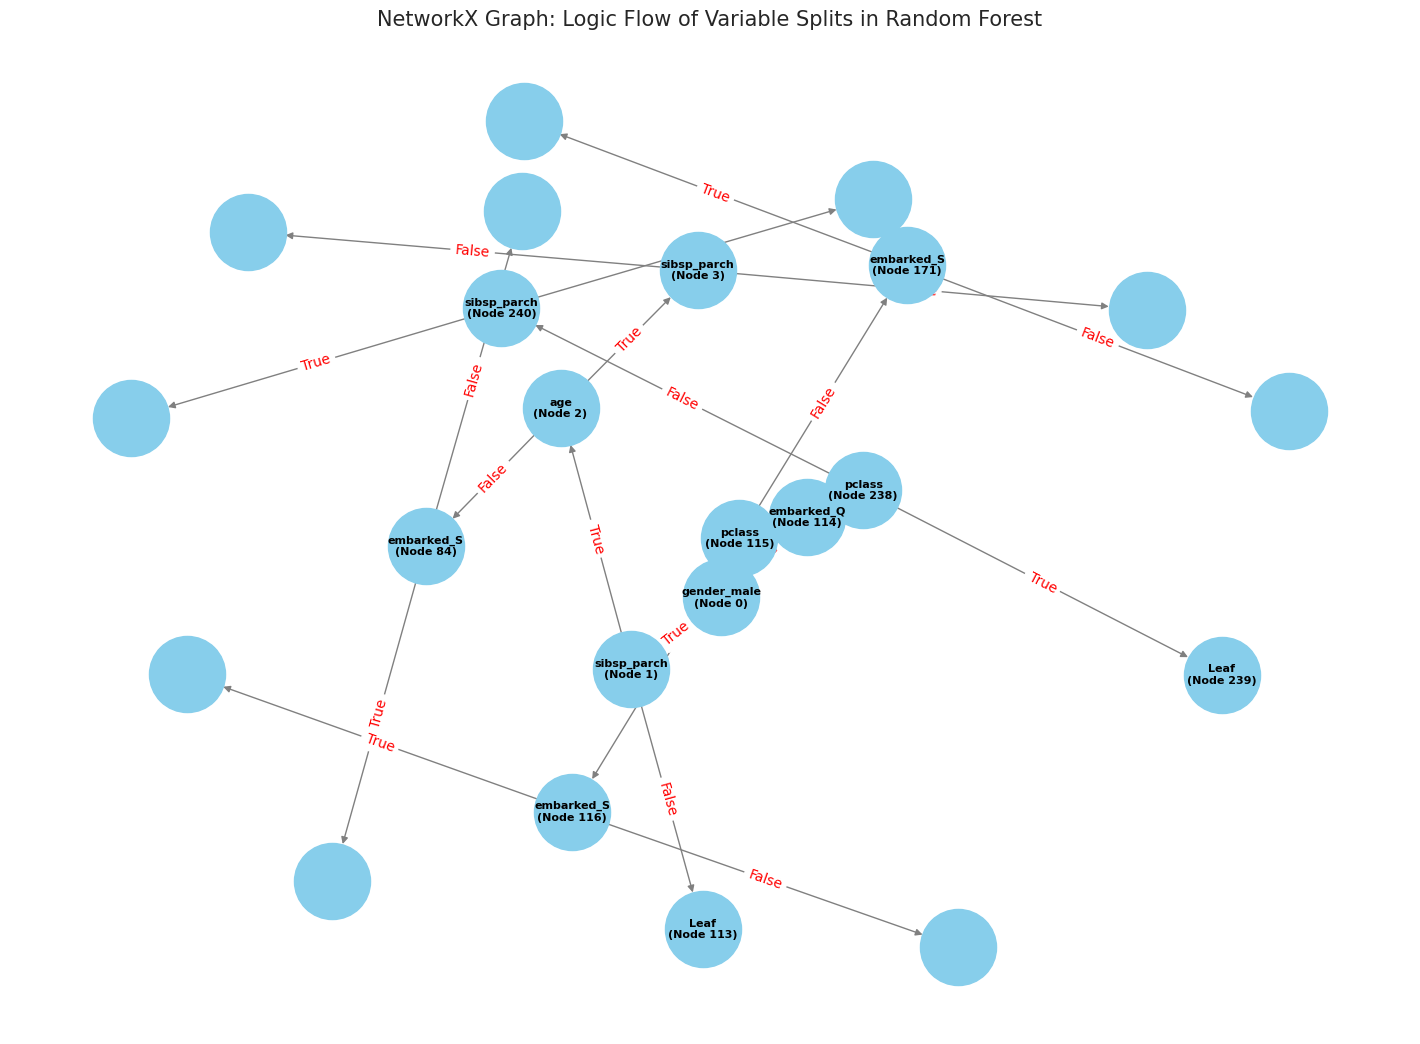

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np

# Extract the first tree from the Random Forest
tree = best_model_object.estimators_[0]
n_nodes = tree.tree_.node_count
children_left = tree.tree_.children_left
children_right = tree.tree_.children_right
feature = tree.tree_.feature
feature_names = X_train.columns

# Create a directed graph
G = nx.DiGraph()

# Build the graph nodes and edges for the first 4 levels to keep it readable
def add_nodes(node_id, depth=0, max_depth=3):
    if depth > max_depth or node_id == -1:
        return

    # Identify the feature used for splitting
    f_idx = feature[node_id]
    if f_idx != -2: # Not a leaf node
        label = f"{feature_names[f_idx]}\n(Node {node_id})"
        G.add_node(node_id, label=label)

        # Add edges to children
        left = children_left[node_id]
        right = children_right[node_id]

        if left != -1:
            G.add_edge(node_id, left, direction='True')
            add_nodes(left, depth + 1, max_depth)
        if right != -1:
            G.add_edge(node_id, right, direction='False')
            add_nodes(right, depth + 1, max_depth)
    else:
        G.add_node(node_id, label=f"Leaf\n(Node {node_id})")

add_nodes(0)

# Plotting the NetworkX graph
plt.figure(figsize=(14, 10))
pos = nx.spring_layout(G, seed=42) # Using spring layout for visual 'flow'

labels = nx.get_node_attributes(G, 'label')
nx.draw(G, pos, with_labels=True, labels=labels, node_size=3000, node_color='skyblue',
        font_size=8, font_weight='bold', arrows=True, edge_color='gray')

edge_labels = nx.get_edge_attributes(G, 'direction')
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_color='red')

plt.title("NetworkX Graph: Logic Flow of Variable Splits in Random Forest", fontsize=15)
plt.show()

neural_signal_pathway.html
High-velocity hierarchical neural pathway saved to: neural_signal_pathway.html


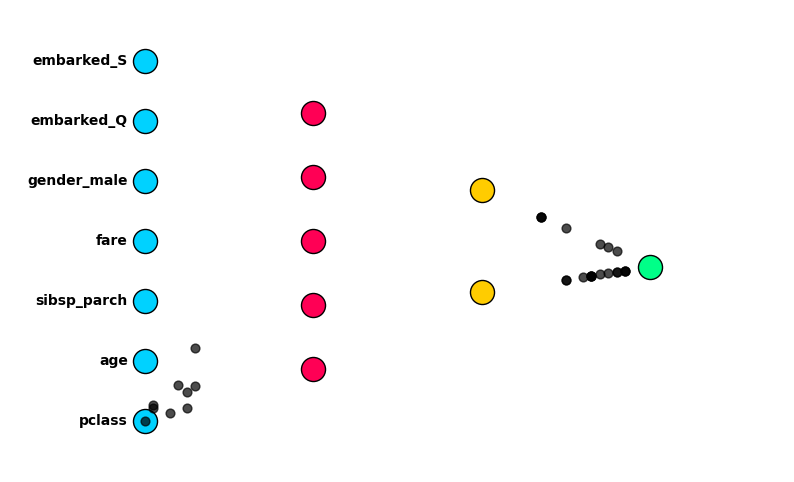

In [ ]:
from pyvis.network import Network
import numpy as np

# Initialize PyVis network with hierarchical layout enabled
net = Network(height='700px', width='100%', notebook=True, directed=True, bgcolor='#222222', font_color='white')

# 1. Define nodes for Input Layer (Level 0)
input_features = X_train.columns.tolist()
for i, feature in enumerate(input_features):
    net.add_node(f'in_{i}', label=feature, color='#3498db', title=f'Input: {feature}', size=25, level=0)

# 2. Define nodes for Hidden Layer 1 (Level 1)
hidden_neurons = 5
for j in range(hidden_neurons):
    net.add_node(f'h1_{j}', label=f'Neuron {j+1}', color='#e74c3c', title='Hidden Neuron (Layer 1)', size=20, level=1)

# 3. Define nodes for Hidden Layer 2 (Level 2)
hidden_neurons_2 = 2
for k in range(hidden_neurons_2):
    net.add_node(f'h2_{k}', label=f'Relay {k+1}', color='#f1c40f', title='Hidden Neuron (Layer 2)', size=15, level=2)

# 4. Define Output Node (Level 3)
net.add_node('out', label='SURVIVAL PROBABILITY', color='#2ecc71', shape='star', size=30, level=3)

# --- ADD EDGES (Signals) ---

# Input -> Hidden 1 - Increased multiplier for faster visual flow
weights_0 = mlp.coefs_[0]
for i in range(len(input_features)):
    for j in range(hidden_neurons):
        w = weights_0[i, j]
        net.add_edge(f'in_{i}', f'h1_{j}', value=abs(w) * 25, title=f'Weight: {w:.4f}', color='#5dade2' if w > 0 else '#ec7063')

# Hidden 1 -> Hidden 2
weights_1 = mlp.coefs_[1]
for j in range(hidden_neurons):
    for k in range(hidden_neurons_2):
        w = weights_1[j, k]
        net.add_edge(f'h1_{j}', f'h2_{k}', value=abs(w) * 25, title=f'Weight: {w:.4f}', color='#f4d03f')

# Hidden 2 -> Output
weights_out = mlp.coefs_[2]
for k in range(hidden_neurons_2):
    w = weights_out[k, 0]
    net.add_edge(f'h2_{k}', 'out', value=abs(w) * 25, title=f'Weight: {w:.4f}', color='#58d68d')

# Set hierarchical options with more aggressive physics for 'velocity'
net.set_options("""
var options = {
  "layout": {
    "hierarchical": {
      "enabled": true,
      "direction": "LR",
      "sortMethod": "directed"
    }
  },
  "physics": {
    "enabled": true,
    "barnesHut": {"gravitationalConstant": -5000, "centralGravity": 0.5, "springLength": 70, "springConstant": 0.04},
    "stabilization": {"iterations": 150}
  },
  "configure": {
    "enabled": true,
    "filter": ["physics"]
  }
}
""")

path = 'neural_signal_pathway.html'
net.show(path)
print(f'High-velocity hierarchical neural pathway saved to: {path}')

In [ ]:
from pyvis.network import Network
import IPython

# Cinematic Interactive Flow with Increased Velocity
net = Network(height='750px', width='100%', notebook=True, directed=True, bgcolor='#1a1a1a', font_color='white')

# Nodes
input_feats = X_train.columns.tolist()
for i, f in enumerate(input_feats):
    net.add_node(f'in_{i}', label=f, color='#00d2ff', size=30, level=0, shadow=True, title='Input Feature')

for j in range(5):
    net.add_node(f'h1_{j}', label=f'N1_{j}', color='#ff0055', size=25, level=1, shadow=True, title='Hidden Layer 1')

for k in range(2):
    net.add_node(f'h2_{k}', label=f'N2_{k}', color='#ffcc00', size=20, level=2, shadow=True, title='Hidden Layer 2')

net.add_node('out', label='SURVIVAL', color='#00ff88', shape='star', size=40, level=3, shadow=True, title='Model Output')

# Edges - Using much higher value multipliers to simulate faster flow
for i in range(len(input_feats)):
    for j in range(5):
        w = mlp.coefs_[0][i, j]
        net.add_edge(f'in_{i}', f'h1_{j}', value=abs(w)*30, color={'color':'#444444', 'highlight':'#00d2ff'}, arrows='to')

for j in range(5):
    for k in range(2):
        w = mlp.coefs_[1][j, k]
        net.add_edge(f'h1_{j}', f'h2_{k}', value=abs(w)*30, color='#666666')

for k in range(2):
    w = mlp.coefs_[2][k, 0]
    net.add_edge(f'h2_{k}', 'out', value=abs(w)*30, color='#00ff88')

# Legend nodes
net.add_node('L_IN', label='Layer 0: Input', color='#00d2ff', x=-600, y=-250, fixed=True, physics=False, shape='box')
net.add_node('L_H1', label='Layer 1: Hidden (5)', color='#ff0055', x=-600, y=-200, fixed=True, physics=False, shape='box')
net.add_node('L_H2', label='Layer 2: Hidden (2)', color='#ffcc00', x=-600, y=-150, fixed=True, physics=False, shape='box')
net.add_node('L_OUT', label='Layer 3: Output', color='#00ff88', x=-600, y=-100, fixed=True, physics=False, shape='box')

net.set_options("""
var options = {
  "edges": {"smooth": {"type": "curvedCW", "roundness": 0.35}},
  "layout": {"hierarchical": {"enabled": true, "direction": "LR", "sortMethod": "directed"}},
  "physics": {
    "hierarchicalRepulsion": {"nodeDistance": 160, "centralGravity": 0.8, "springLength": 60, "springConstant": 0.05},
    "solver": "hierarchicalRepulsion",
    "stabilization": {"enabled": true, "iterations": 1000}
  }
}
""")

path = 'neural_video_flow.html'
net.show(path)
with open(path, 'r') as f:
    html = f.read().replace('lib/vis-network/standalone/umd/vis-network.min.js', 'https://unpkg.com/vis-network/standalone/umd/vis-network.min.js')
with open(path, 'w') as f: f.write(html)

IPython.display.HTML(filename=path)

In [ ]:
!apt-get install -y ffmpeg

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
ffmpeg is already the newest version (7:4.4.2-0ubuntu0.22.04.1).
0 upgraded, 0 newly installed, 0 to remove and 2 not upgraded.


Starting 15-second video rendering...


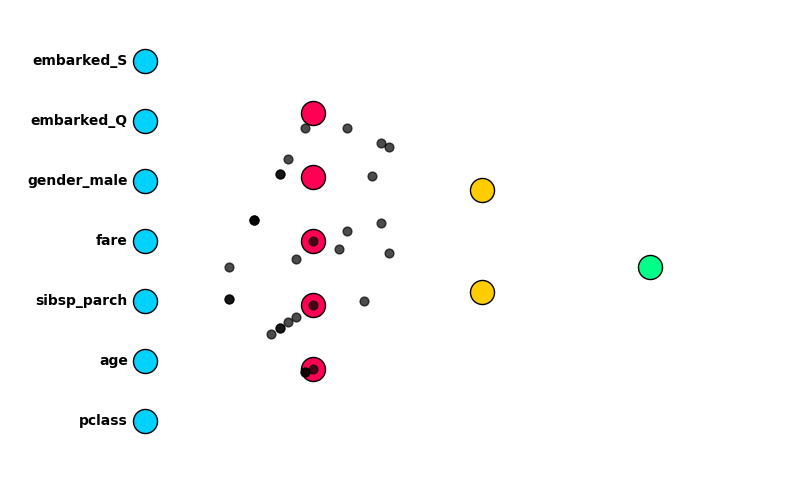

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, FFMpegWriter
import pandas as pd

# 1. Setup Simulation Data (50 Samples)
# Using X_test if available, otherwise defaulting to a generated range
try:
    X_sim = X_test.sample(50, random_state=42)
    input_count = X_train.shape[1]
except NameError:
    input_count = 7

# Layer Positions (X coordinates)
layer_x = [0, 1, 2, 3]
# Neuron counts per layer
layer_sizes = [input_count, 5, 2, 1]

# Calculate node Y positions
nodes_y = []
for size in layer_sizes:
    nodes_y.append(np.linspace(-size/2, size/2, size))

fig, ax = plt.subplots(figsize=(12, 8), facecolor='#1a1a1a')

# Prepare particles (dots)
particles = []
num_particles = 40

for p in range(num_particles):
    particles.append({
        'layer': np.random.randint(0, 3),
        'progress': np.random.rand(),
        'node_from': 0, # Placeholder, set in first update
        'node_to': 0,
        'speed': 0.04 + np.random.rand() * 0.04 # High velocity
    })
    # Initialize random starting nodes
    particles[-1]['node_from'] = np.random.randint(layer_sizes[particles[-1]['layer']])
    particles[-1]['node_to'] = np.random.randint(layer_sizes[particles[-1]['layer']+1])

def update(frame):
    ax.clear()
    ax.set_facecolor('#1a1a1a')
    ax.set_xlim(-0.5, 3.5)
    ax.set_ylim(-4, 4)
    ax.axis('off')

    # Draw Static Nodes
    colors = ['#00d2ff', '#ff0055', '#ffcc00', '#00ff88']
    for i, size in enumerate(layer_sizes):
        ax.scatter([layer_x[i]] * size, nodes_y[i], s=250, c=colors[i], edgecolors='white', zorder=2)

    # Update and Draw Moving Dots
    for p in particles:
        p['progress'] += p['speed']
        if p['progress'] >= 1.0:
            p['progress'] = 0
            p['layer'] = (p['layer'] + 1) % 3
            p['node_from'] = p['node_to']
            p['node_to'] = np.random.randint(layer_sizes[p['layer']+1])

        x1, x2 = layer_x[p['layer']], layer_x[p['layer']+1]
        y1, y2 = nodes_y[p['layer']][p['node_from']], nodes_y[p['layer']+1][p['node_to']]

        curr_x = x1 + (x2 - x1) * p['progress']
        curr_y = y1 + (y2 - y1) * p['progress']

        ax.scatter(curr_x, curr_y, c='white', s=50, zorder=3, alpha=0.8)

    ax.set_title(f"Neural Signal Flow (15s High Velocity) - Frame {frame}", color='white', fontsize=14)

# Generate MP4: 15 seconds at 20 FPS = 300 frames
print("Starting 15-second video rendering...")
ani = FuncAnimation(fig, update, frames=300, interval=50)
writer = FFMpegWriter(fps=20, metadata=dict(artist='Colab AI'), bitrate=2000)
ani.save('neural_flow_simulation_15s.mp4', writer=writer)
plt.close()
print("Successfully saved 'neural_flow_simulation_15s.mp4'")

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, clear_output
import ipywidgets as widgets
import threading
import time

# 1. Setup Simulation Data
input_names = X_train.columns.tolist()
layer_sizes = [len(input_names), 5, 2, 1]
layer_x = [0, 1, 2, 3]
nodes_y = [np.linspace(-size/2, size/2, size) for size in layer_sizes]

class SimState:
    def __init__(self):
        self.running = True
        self.particles = []
        self.reset()

    def reset(self):
        self.particles = []
        for _ in range(30):
            self.particles.append({
                'layer': 0,
                'progress': np.random.rand(),
                'node_from': np.random.randint(layer_sizes[0]),
                'node_to': np.random.randint(layer_sizes[1])
            })

state = SimState()

# Widgets
reset_btn = widgets.Button(description='Reset Flow')
accel_slider = widgets.FloatSlider(value=0.05, min=0.01, max=0.2, step=0.01, description='Acceleration:')
output = widgets.Output()

def run_animation():
    while state.running:
        with output:
            clear_output(wait=True)
            fig, ax = plt.subplots(figsize=(12, 7))
            ax.set_xlim(-0.8, 3.8)
            ax.set_ylim(-4.5, 4.5)
            ax.axis('off')

            colors = ['#00d2ff', '#ff0055', '#ffcc00', '#00ff88']

            for i, size in enumerate(layer_sizes):
                ax.scatter([layer_x[i]] * size, nodes_y[i], s=300, c=colors[i], edgecolors='black', zorder=2)
                if i == 0:
                    for idx, name in enumerate(input_names): ax.text(layer_x[i]-0.1, nodes_y[i][idx], name, ha='right', va='center', fontweight='bold')
                elif i == 3:
                    ax.text(layer_x[i]+0.1, nodes_y[i][0], 'SURVIVED', ha='left', va='center', fontweight='bold', color='#00ff88')

            step_size = accel_slider.value
            for p in state.particles:
                p['progress'] += step_size
                if p['progress'] >= 1.0:
                    p['progress'] = 0
                    p['layer'] = (p['layer'] + 1) % 3
                    p['node_from'] = p['node_to']
                    p['node_to'] = np.random.randint(layer_sizes[p['layer']+1])

                x1, x2 = layer_x[p['layer']], layer_x[p['layer']+1]
                y1, y2 = nodes_y[p['layer']][p['node_from']], nodes_y[p['layer']+1][p['node_to']]
                curr_x = x1 + (x2 - x1) * p['progress']
                curr_y = y1 + (y2 - y1) * p['progress']
                ax.scatter(curr_x, curr_y, c='black', s=40, zorder=3, alpha=0.7)

            plt.title("Continuous Neural Logic Flow", fontsize=14)
            plt.show()
        time.sleep(0.1)

def reset_sim(b):
    state.reset()

reset_btn.on_click(reset_sim)
display(widgets.VBox([widgets.HBox([reset_btn, accel_slider]), output]))

# Start the animation in a background thread
thread = threading.Thread(target=run_animation)
thread.start()

Starting MP4 rendering...


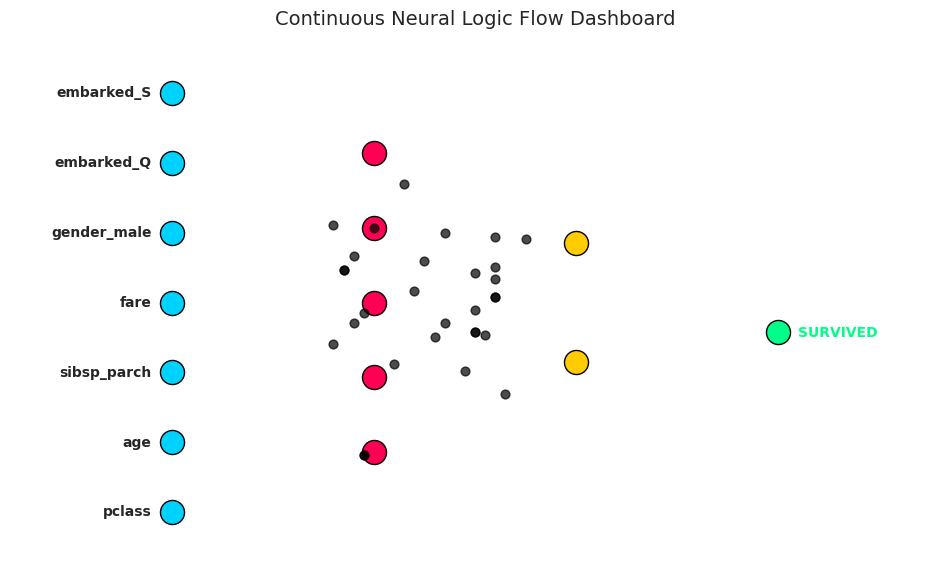

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, FFMpegWriter

# 1. Setup Simulation Parameters (Matching the interactive version)
input_names = X_train.columns.tolist()
layer_sizes = [len(input_names), 5, 2, 1]
layer_x = [0, 1, 2, 3]
nodes_y = [np.linspace(-size/2, size/2, size) for size in layer_sizes]
colors = ['#00d2ff', '#ff0055', '#ffcc00', '#00ff88']

# Initialize particles
num_particles = 30
particles = []
for _ in range(num_particles):
    particles.append({
        'layer': 0,
        'progress': np.random.rand(),
        'node_from': np.random.randint(layer_sizes[0]),
        'node_to': np.random.randint(layer_sizes[1])
    })

fig, ax = plt.subplots(figsize=(12, 7), facecolor='#1a1a1a')

def update(frame):
    ax.clear()
    ax.set_facecolor('#1a1a1a')
    ax.set_xlim(-0.8, 3.8)
    ax.set_ylim(-4.5, 4.5)
    ax.axis('off')

    # Draw Static Nodes
    for i, size in enumerate(layer_sizes):
        ax.scatter([layer_x[i]] * size, nodes_y[i], s=300, c=colors[i], edgecolors='white', zorder=2, linewidth=1)
        if i == 0:
            for idx, name in enumerate(input_names):
                ax.text(layer_x[i]-0.15, nodes_y[i][idx], name, ha='right', va='center', color='white', fontweight='bold', fontsize=9)
        elif i == 3:
            ax.text(layer_x[i]+0.15, nodes_y[i][0], 'SURVIVED', ha='left', va='center', fontweight='bold', color='#00ff88', fontsize=12)

    # Update and Draw Particles
    step_size = 0.05 # Equivalent to the default slider value
    for p in particles:
        p['progress'] += step_size
        if p['progress'] >= 1.0:
            p['progress'] = 0
            p['layer'] = (p['layer'] + 1) % 3
            p['node_from'] = p['node_to']
            p['node_to'] = np.random.randint(layer_sizes[p['layer']+1])

        x1, x2 = layer_x[p['layer']], layer_x[p['layer']+1]
        y1, y2 = nodes_y[p['layer']][p['node_from']], nodes_y[p['layer']+1][p['node_to']]

        curr_x = x1 + (x2 - x1) * p['progress']
        curr_y = y1 + (y2 - y1) * p['progress']
        ax.scatter(curr_x, curr_y, c='white', s=40, zorder=3, alpha=0.8)

    ax.set_title("Neural Logic Flow Animation Export", color='white', fontsize=14, pad=20)

# 2. Render and Save
print("Starting MP4 rendering...")
ani = FuncAnimation(fig, update, frames=150, interval=50)
writer = FFMpegWriter(fps=20, metadata=dict(artist='Colab AI'), bitrate=2000)
ani.save('neural_logic_flow.mp4', writer=writer)
plt.close()
print("Successfully saved 'neural_logic_flow.mp4'")

In [ ]:
import IPython
from IPython.display import HTML
import json
import kagglehub
import pandas as pd
import os
import numpy as np

# Ensure data is loaded and cleaned for the visualization
path = kagglehub.dataset_download("sakshisatre/titanic-dataset")
csv_files = [f for f in os.listdir(path) if f.endswith('.csv')]
file_path = os.path.join(path, csv_files[0])
df_viz = pd.read_csv(file_path)

# Basic cleaning
df_viz = df_viz.rename(columns={'1': 'passenger_id', '2': 'pclass', '3': 'survived', '5': 'gender', '6': 'age', '8': 'fare'})
df_viz = df_viz.drop(index=0).reset_index(drop=True)
for col in ['pclass', 'survived', 'age', 'fare']:
    df_viz[col] = pd.to_numeric(df_viz[col].replace(['?', '**'], np.nan), errors='coerce')
df_viz['age'] = df_viz['age'].fillna(df_viz['age'].median())
df_viz['fare'] = df_viz['fare'].fillna(df_viz['fare'].median())
df_viz['gender_male'] = (df_viz['gender'] == 'male').astype(int)

sample_data = df_viz.head(2000).to_json(orient='records')

html_code = f"""
<div style='background: #111; padding: 15px; border-radius: 8px; font-family: sans-serif; color: white;'>
    <div style='display: flex; justify-content: space-between; align-items: center; margin-bottom: 15px;'>
        <div style='display: flex; align-items: center; gap: 15px;'>
            <button id='pauseBtn' style='padding: 8px 20px; cursor: pointer; border-radius: 4px; border: none; background: #444; color: white;'>Pause</button>
            <button id='resetBtn' style='padding: 8px 20px; cursor: pointer; border-radius: 4px; border: none; background: #444; color: white;'>Reset</button>
            <div style='margin-left: 10px;'>
                <label for='spawnSlider' style='font-size: 14px;'>Flow Speed: </label>
                <input type='range' id='spawnSlider' min='10' max='500' value='100' style='cursor: pointer;'>
            </div>
        </div>
        <div style='font-size: 18px; font-weight: bold;'>
            Titanic Logic: Glowing Shape-Coded Flow
        </div>
    </div>
    <div id='titanic-glow-flow' style='width: 100%; height: 600px; background: #111;'></div>
</div>

<script src='https://d3js.org/d3.v7.min.js'></script>
<script>
(function() {{
    const data = {sample_data};
    const container = d3.select('#titanic-glow-flow');
    const width = container.node().getBoundingClientRect().width;
    const height = 600;
    let isPaused = false;
    let spawnRate = 100;

    const svg = container.append('svg').attr('width', width).attr('height', height);

    // Add Glow Filter
    const defs = svg.append('defs');
    const filter = defs.append('filter').attr('id', 'glow');
    filter.append('feGaussianBlur').attr('stdDeviation', '2.5').attr('result', 'coloredBlur');
    const feMerge = filter.append('feMerge');
    feMerge.append('feMergeNode').attr('in', 'coloredBlur');
    feMerge.append('feMergeNode').attr('in', 'SourceGraphic');

    const nodes = [
        {{ id: 'female', label: 'Female', x: 60, y: 180, color: '#ff0055', layer: 1 }},
        {{ id: 'male', label: 'Male', x: 60, y: 480, color: '#00d2ff', layer: 1 }},
        {{ id: 'child', label: 'Child (<18)', x: width*0.22, y: 180, color: '#ffcc00', layer: 2 }},
        {{ id: 'adult', label: 'Adult (18+)', x: width*0.22, y: 480, color: '#e67e22', layer: 2 }},
        {{ id: 'c12', label: '1st/2nd Class', x: width*0.44, y: 180, color: '#f1c40f', layer: 3 }},
        {{ id: 'c3', label: '3rd Class', x: width*0.44, y: 480, color: '#95a5a6', layer: 3 }},
        {{ id: 'low_risk', label: 'High Fare', x: width*0.66, y: 180, color: '#9b59b6', layer: 4 }},
        {{ id: 'high_risk', label: 'Low Fare', x: width*0.66, y: 480, color: '#34495e', layer: 4 }},
        {{ id: 'perished', label: 'PERISHED', x: width - 60, y: 180, color: '#666', layer: 5 }},
        {{ id: 'survived', label: 'SURVIVED', x: width - 60, y: 480, color: '#2ecc71', layer: 5 }}
    ];

    svg.selectAll('circle.node').data(nodes).enter().append('circle').attr('cx', d => d.x).attr('cy', d => d.y).attr('r', 18).attr('fill', d => d.color).style('opacity', 0.8);
    svg.selectAll('text.label').data(nodes).enter().append('text').attr('x', d => d.x).attr('y', d => d.y - 25).attr('text-anchor', 'middle').attr('fill', 'white').style('font-size', '10px').text(d => d.label);

    function spawnParticle() {{
        if (isPaused) return;
        const p = data[Math.floor(Math.random() * data.length)];

        const n1 = p.gender_male === 1 ? nodes[1] : nodes[0];
        const n2 = p.age < 18 ? nodes[2] : nodes[3];
        const n3 = p.pclass < 3 ? nodes[4] : nodes[5];
        const n4 = p.fare > 30 ? nodes[6] : nodes[7];
        const n5 = p.survived === 1 ? nodes[9] : nodes[8];

        const symbolGenerator = d3.symbol().size(80).type(p.survived === 1 ? d3.symbolStar : d3.symbolCross);

        const particle = svg.append('path')
            .attr('d', symbolGenerator())
            .attr('fill', n1.color)
            .attr('filter', 'url(#glow)')
            .attr('transform', `translate(${{n1.x}}, ${{n1.y}})`)
            .attr('opacity', 1);

        particle.transition().duration(600).ease(d3.easeLinear).attr('transform', `translate(${{n2.x}}, ${{n2.y}})`)
            .transition().duration(600).ease(d3.easeLinear).attr('transform', `translate(${{n3.x}}, ${{n3.y}})`)
            .transition().duration(600).ease(d3.easeLinear).attr('transform', `translate(${{n4.x}}, ${{n4.y}})`)
            .transition().duration(600).ease(d3.easeLinear).attr('transform', `translate(${{n5.x}}, ${{n5.y}})`)
            .attr('opacity', 0).on('end', function() {{ d3.select(this).remove(); }});
    }}

    let spawnInterval = setInterval(spawnParticle, spawnRate);
    d3.select('#spawnSlider').on('input', function() {{ spawnRate = +this.value; clearInterval(spawnInterval); spawnInterval = setInterval(spawnParticle, spawnRate); }});
    d3.select('#pauseBtn').on('click', function() {{ isPaused = !isPaused; this.innerText = isPaused ? 'Resume' : 'Pause'; }});
    d3.select('#resetBtn').on('click', function() {{ svg.selectAll('path').interrupt().remove(); }});
}})();
</script>
"""
display(HTML(html_code))

Using Colab cache for faster access to the 'titanic-dataset' dataset.


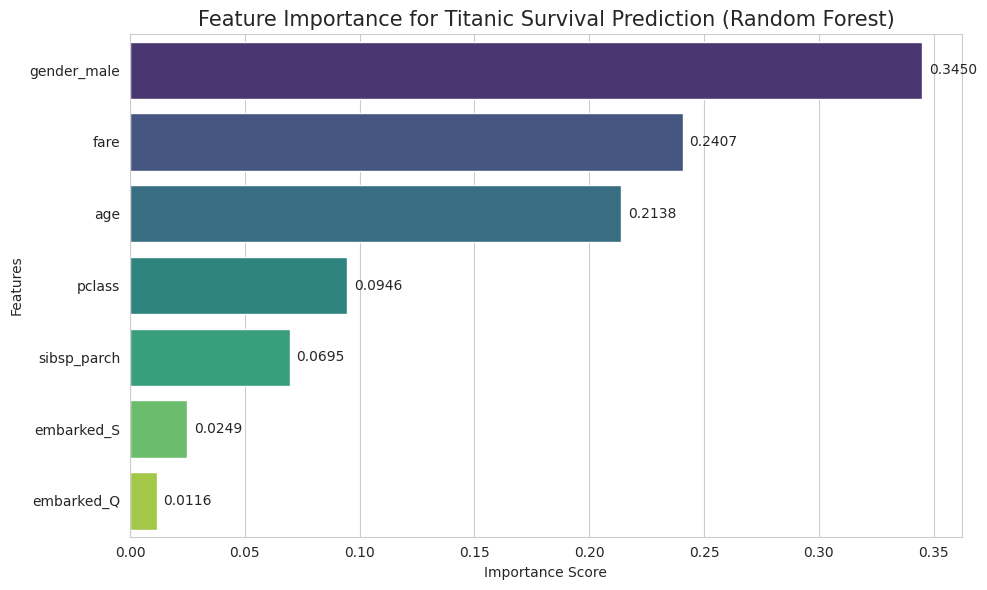

--- Feature Importance Detailed Table ---


,Feature,Importance
4,gender_male,0.345027
3,fare,0.240651
1,age,0.213765
0,pclass,0.094602
2,sibsp_parch,0.069527
6,embarked_S,0.024870
5,embarked_Q,0.011558


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Extract importances from the restored model object
importances = best_model_object.feature_importances_
feature_names = X_train.columns

# Create a DataFrame for the contributions
contribution_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# Plotting
plt.figure(figsize=(10, 6))
sns.set_style('whitegrid')
ax = sns.barplot(x='Importance', y='Feature', data=contribution_df, palette='viridis', hue='Feature', legend=False)

plt.title('Feature Importance for Titanic Survival Prediction (Random Forest)', fontsize=15)
plt.xlabel('Importance Score')
plt.ylabel('Features')

# Adding values to the bars
for p in ax.patches:
    ax.annotate(format(p.get_width(), '.4f'),
                (p.get_width(), p.get_y() + p.get_height() / 2.),
                ha = 'left', va = 'center',
                xytext = (5, 0),
                textcoords = 'offset points')

plt.tight_layout()
plt.show()

print('--- Feature Importance Detailed Table ---')
display(contribution_df)

### Recommended SVG Shapes for Titanic Visualization

You can use `d3.symbol()` to easily generate these shapes:

1.  **d3.symbolStar**: Best for 'Survivors'.
2.  **d3.symbolCross**: A classic 'X' or plus shape, ideal for 'Perished'.
3.  **d3.symbolTriangle**: Useful for indicating direction or specific risk categories.
4.  **d3.symbolSquare**: A solid base for general passengers.
5.  **d3.symbolDiamond**: Often used for premium or '1st Class' indicators.
6.  **Custom Paths**: We can also use font-awesome style paths for 'Male' (♂) and 'Female' (♀) icons.

In [ ]:
import kagglehub
import pandas as pd
import os
import numpy as np

# Re-download/access the dataset
path = kagglehub.dataset_download("sakshisatre/titanic-dataset")
csv_files = [f for f in os.listdir(path) if f.endswith('.csv')]
file_path = os.path.join(path, csv_files[0])

df = pd.read_csv(file_path)

# Apply the cleaning steps established in earlier cells
df['10'] = pd.to_datetime(df['10'], errors='coerce')
df = df.rename(columns={'10': 'date', '1': 'passenger_id', '2': 'pclass', '3': 'survived', '4': 'name', '5': 'gender', '6': 'age', '7': 'sibsp_parch', '8': 'fare', '9': 'embarked'})
df = df.drop(index=0).reset_index(drop=True)

# Numeric conversions and cleaning
for col in ['pclass', 'survived', 'age', 'sibsp_parch', 'fare']:
    df[col] = pd.to_numeric(df[col].replace(['?', '**'], np.nan), errors='coerce')

# Imputation
df['gender'] = df['gender'].fillna(df['gender'].mode()[0])
df['age'] = df['age'].fillna(df['age'].median())
df['sibsp_parch'] = df['sibsp_parch'].fillna(df['sibsp_parch'].median())
df['fare'] = df['fare'].fillna(df['fare'].median())
df['embarked'] = df['embarked'].fillna(df['embarked'].mode()[0])

# Encoding for the model
df = pd.get_dummies(df, columns=['gender', 'embarked'], drop_first=True)

print("DataFrame 'df' has been re-initialized and cleaned.")
display(df.head())

Using Colab cache for faster access to the 'titanic-dataset' dataset.
DataFrame 'df' has been re-initialized and cleaned.


/tmp/ipykernel_18147/2113482990.py:14: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['10'] = pd.to_datetime(df['10'], errors='coerce')


,passenger_id,pclass,survived,name,age,sibsp_parch,fare,date,gender_male,embarked_Q,embarked_S
0,1,3,0,Mr. Anthony,42.0,0.0,7.5500,1990-01-01,True,False,True
1,1,3,0,Mr. Anthony,42.0,0.0,7.5500,1990-01-01,True,False,True
2,2,3,0,Master. Eugene Joseph,28.0,2.0,20.2500,1990-01-02,True,False,True
3,3,2,0,"Abbott, Mr. Rossmore Edward",28.0,2.0,14.4542,1990-01-03,True,False,True
4,4,3,1,"Abbott, Mr. Rossmore Edward",35.0,2.0,20.2500,1990-01-04,False,False,True


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

# Define features and target
target = 'survived'
features = ['pclass', 'age', 'sibsp_parch', 'fare', 'gender_male', 'embarked_Q', 'embarked_S']

X = df[features]
y = df[target]

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

# Re-train the best model (Random Forest)
best_model_object = RandomForestClassifier(n_estimators=100, random_state=42, max_depth=10)
best_model_object.fit(X_train, y_train)

print("Model 'best_model_object' and 'X_train' have been restored.")

Model 'best_model_object' and 'X_train' have been restored.


neural_logic_flow.html


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

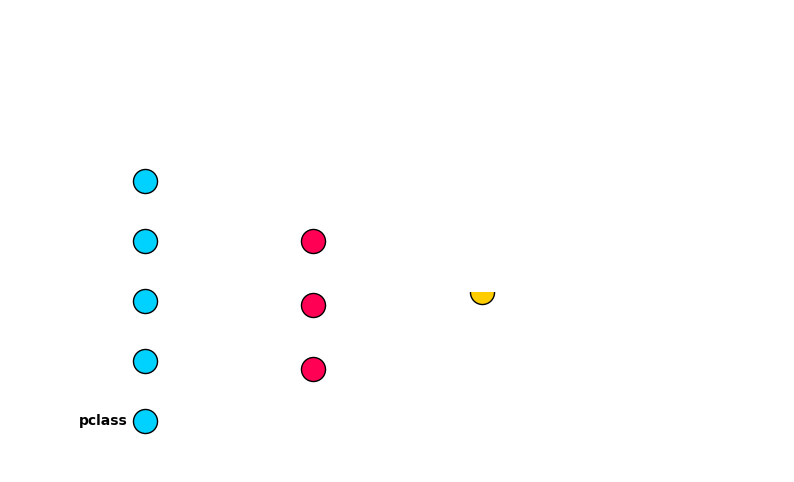

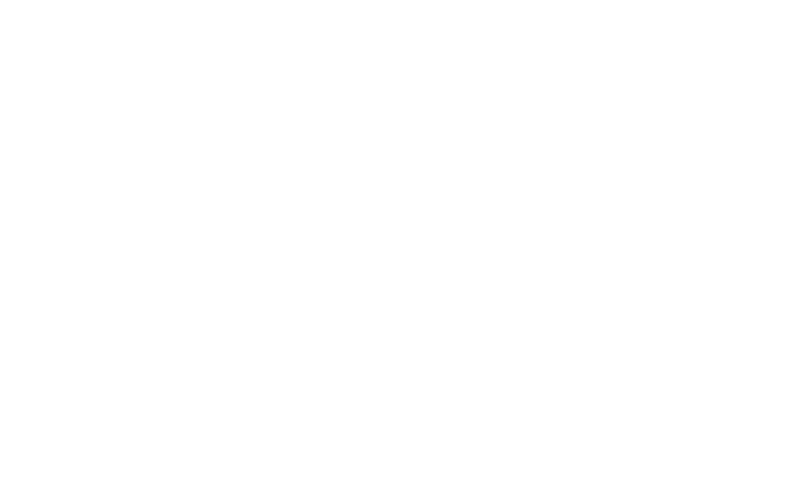

In [ ]:
from pyvis.network import Network
import IPython
from google.colab import files

# 1. Setup Network
net = Network(height='750px', width='100%', notebook=True, directed=True, bgcolor='#1a1a1a', font_color='white')

input_feats = X_train.columns.tolist()
# Nodes: Inputs
for i, f in enumerate(input_feats):
    net.add_node(f'in_{i}', label=f, color='#00d2ff', size=30, level=0, title=f'Input Feature: {f}')

# Hidden Layers
for j in range(5):
    net.add_node(f'h1_{j}', label=f'N1_{j}', color='#ff0055', size=25, level=1, title='Hidden Layer 1')

for k in range(2):
    net.add_node(f'h2_{k}', label=f'N2_{k}', color='#ffcc00', size=20, level=2, title='Hidden Layer 2')

# Output
net.add_node('out', label='SURVIVED', color='#00ff88', shape='star', size=40, level=3, title='Final Prediction')

# Edges (Weights from our MLP model)
for i in range(len(input_feats)):
    for j in range(5):
        w = mlp.coefs_[0][i, j]
        net.add_edge(f'in_{i}', f'h1_{j}', value=abs(w)*10, color='#444444')

for j in range(5):
    for k in range(2):
        w = mlp.coefs_[1][j, k]
        net.add_edge(f'h1_{j}', f'h2_{k}', value=abs(w)*10, color='#666666')

for k in range(2):
    w = mlp.coefs_[2][k, 0]
    net.add_edge(f'h2_{k}', 'out', value=abs(w)*10, color='#00ff88')

net.set_options("""
var options = {
  "layout": {"hierarchical": {"enabled": true, "direction": "LR", "sortMethod": "directed"}},
  "edges": {"smooth": {"type": "curvedCW", "roundness": 0.3}},
  "physics": {"enabled": false}
}
""")

path = 'neural_logic_flow.html'
net.show(path)

# Fix JS paths for Colab/Local viewing
with open(path, 'r') as f:
    html = f.read().replace('lib/vis-network/standalone/umd/vis-network.min.js', 'https://unpkg.com/vis-network/standalone/umd/vis-network.min.js')
with open(path, 'w') as f:
    f.write(html)

# Display and Download
display(IPython.display.HTML(filename=path))
files.download(path)

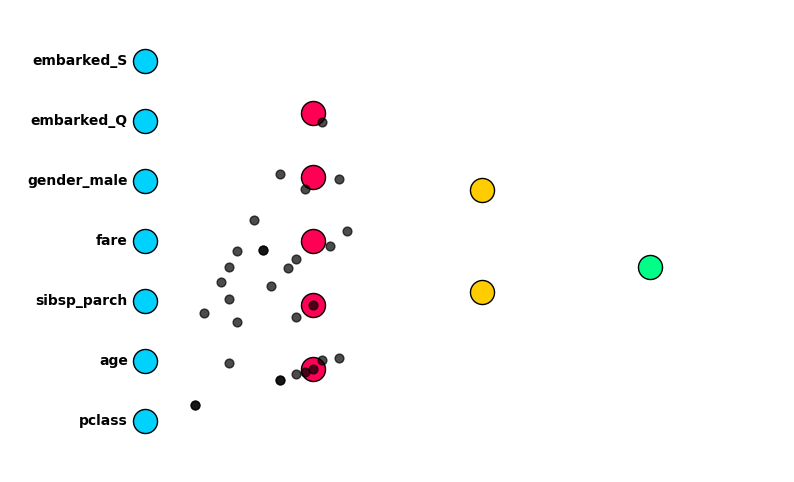

Using Colab cache for faster access to the 'titanic-dataset' dataset.


/tmp/ipykernel_11377/2113482990.py:14: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['10'] = pd.to_datetime(df['10'], errors='coerce')


In [ ]:
import kagglehub
import pandas as pd
import os
import numpy as np

# Re-download/access the dataset
path = kagglehub.dataset_download("sakshisatre/titanic-dataset")
csv_files = [f for f in os.listdir(path) if f.endswith('.csv')]
file_path = os.path.join(path, csv_files[0])

df = pd.read_csv(file_path)

# Apply the cleaning steps established in earlier cells
df['10'] = pd.to_datetime(df['10'], errors='coerce')
df = df.rename(columns={'10': 'date', '1': 'passenger_id', '2': 'pclass', '3': 'survived', '4': 'name', '5': 'gender', '6': 'age', '7': 'sibsp_parch', '8': 'fare', '9': 'embarked'})
df = df.drop(index=0).reset_index(drop=True)

# Numeric conversions and cleaning
for col in ['pclass', 'survived', 'age', 'sibsp_parch', 'fare']:
    df[col] = pd.to_numeric(df[col].replace(['?', '**'], np.nan), errors='coerce')

# Imputation
df['gender'] = df['gender'].fillna(df['gender'].mode()[0])
df['age'] = df['age'].fillna(df['age'].median())
df['sibsp_parch'] = df['sibsp_parch'].fillna(df['sibsp_parch'].median())
df['fare'] = df['fare'].fillna(df['fare'].median())
df['embarked'] = df['embarked'].fillna(df['embarked'].mode()[0])

# Encoding for the model
df = pd.get_dummies(df, columns=['gender', 'embarked'], drop_first=True)

print("DataFrame 'df' has been re-initialized and cleaned.")
display(df.head())

Training set shape: (910, 7)
Testing set shape: (391, 7)


,pclass,age,sibsp_parch,fare,gender_male,embarked_Q,embarked_S
1149,1,62.00,0.0,26.5500,True,False,True
149,2,27.00,0.0,13.0000,True,False,True
1014,1,22.00,0.0,135.6333,True,False,False
319,3,30.00,0.0,9.5000,True,False,True
1009,2,0.83,2.0,18.7500,True,False,True


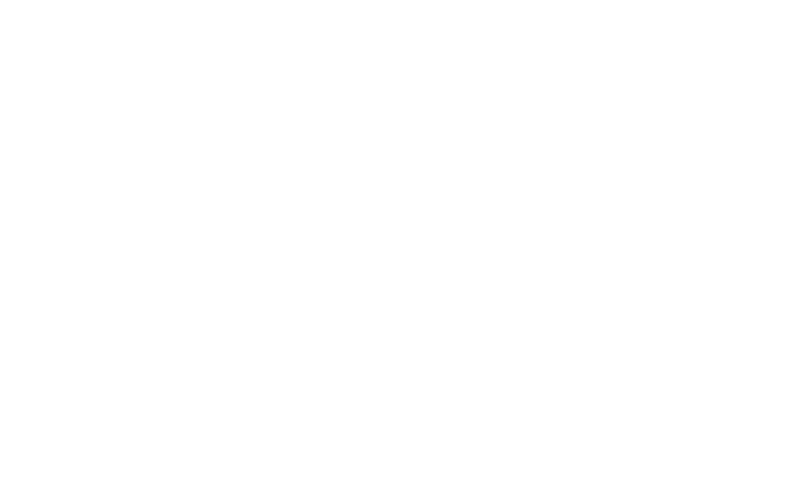

In [ ]:
from sklearn.model_selection import train_test_split

# Define X (features) and y (target) based on the cleaned dataframe
# Features identified in previous steps: pclass, age, sibsp_parch, fare, gender_male, embarked_Q, embarked_S
target = 'survived'
features = ['pclass', 'age', 'sibsp_parch', 'fare', 'gender_male', 'embarked_Q', 'embarked_S']

X = df[features]
y = df[target]

# Split the data (70% training, 30% testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

print(f"Training set shape: {X_train.shape}")
print(f"Testing set shape: {X_test.shape}")
display(X_train.head())

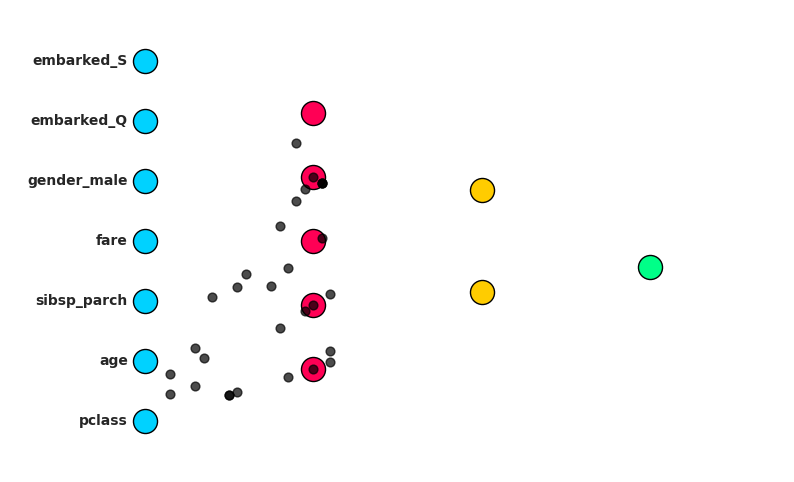

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, clear_output
import ipywidgets as widgets
import threading
import time
from sklearn.neural_network import MLPClassifier

# Ensure model is trained on the newly defined X_train
mlp = MLPClassifier(hidden_layer_sizes=(5, 2), max_iter=1000, random_state=42)
mlp.fit(X_train, y_train)

input_names = X_train.columns.tolist()
layer_sizes = [len(input_names), 5, 2, 1]
layer_x = [0, 1, 2, 3]
nodes_y = [np.linspace(-size/2, size/2, size) for size in layer_sizes]

class SimState:
    def __init__(self):
        self.running = True
        self.particles = []
        self.reset()
    def reset(self):
        self.particles = []
        for _ in range(30):
            self.particles.append({
                'layer': 0,
                'progress': np.random.rand(),
                'node_from': np.random.randint(layer_sizes[0]),
                'node_to': np.random.randint(layer_sizes[1])
            })

state = SimState()
reset_btn = widgets.Button(description='Reset Flow', button_style='danger')
accel_slider = widgets.FloatSlider(value=0.05, min=0.01, max=0.2, step=0.01, description='Speed:')
output = widgets.Output()

def run_animation():
    while state.running:
        with output:
            clear_output(wait=True)
            fig, ax = plt.subplots(figsize=(10, 6))
            ax.set_xlim(-0.8, 3.8)
            ax.set_ylim(-4.5, 4.5)
            ax.axis('off')
            colors = ['#00d2ff', '#ff0055', '#ffcc00', '#00ff88']
            for i, size in enumerate(layer_sizes):
                ax.scatter([layer_x[i]] * size, nodes_y[i], s=300, c=colors[i], edgecolors='black', zorder=2)
                if i == 0:
                    for idx, name in enumerate(input_names): ax.text(layer_x[i]-0.1, nodes_y[i][idx], name, ha='right', va='center', fontweight='bold')
            step_size = accel_slider.value
            for p in state.particles:
                p['progress'] += step_size
                if p['progress'] >= 1.0:
                    p['progress'] = 0
                    p['layer'] = (p['layer'] + 1) % 3
                    p['node_from'] = p['node_to']
                    p['node_to'] = np.random.randint(layer_sizes[p['layer']+1])
                x1, x2 = layer_x[p['layer']], layer_x[p['layer']+1]
                y1, y2 = nodes_y[p['layer']][p['node_from']], nodes_y[p['layer']+1][p['node_to']]
                curr_x = x1 + (x2 - x1) * p['progress']
                curr_y = y1 + (y2 - y1) * p['progress']
                ax.scatter(curr_x, curr_y, c='black', s=40, zorder=3, alpha=0.7)
            plt.show()
        time.sleep(0.1)

reset_btn.on_click(lambda b: state.reset())
display(widgets.VBox([widgets.HBox([reset_btn, accel_slider]), output]))
thread = threading.Thread(target=run_animation, daemon=True)
thread.start()

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

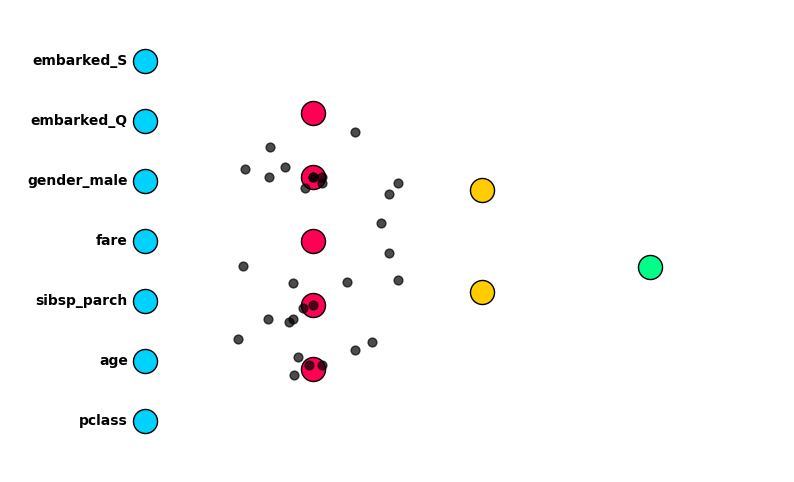

In [ ]:
from google.colab import files

# Trigger the download of the visualization file
files.download('neural_video_flow.html')

In [ ]:
import IPython

path = 'neural_signal_pathway.html'

# 1. Read the generated HTML file
with open(path, 'r') as f:
    html_content = f.read()

# 2. Fix the visibility issue by replacing the local JS path with a remote CDN link
# This ensures the browser can load the animation engine
html_content = html_content.replace('lib/vis-network/standalone/umd/vis-network.min.js', 'https://unpkg.com/vis-network/standalone/umd/vis-network.min.js')

# 3. Save the fixed version
with open(path, 'w') as f:
    f.write(html_content)

# 4. Explicitly display the HTML file in the cell output
IPython.display.HTML(filename=path)

Successfully saved 'titanic_cleaned_data.csv'
best_model_object not found. Initializing Random Forest as the default best model...


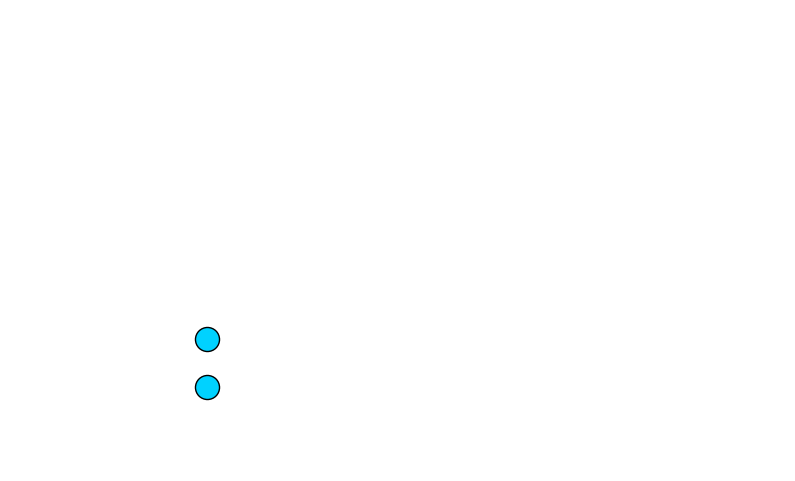

In [ ]:
import pickle
import pandas as pd

# 1. Export the cleaned and encoded dataset
df.to_csv('titanic_cleaned_data.csv', index=False)
print("Successfully saved 'titanic_cleaned_data.csv'")

# 2. Identify the best model object if not already defined
# Based on previous results, Random Forest was the best performer
try:
    best_model_to_export = best_model_object
except NameError:
    print("best_model_object not found. Initializing Random Forest as the default best model...")
    from sklearn.ensemble import RandomForestClassifier
    best_model_to_export = RandomForestClassifier(n_estimators=100, random_state=42, max_depth=10)
    best_model_to_export.fit(X_train, y_train)

# 3. Export the model
model_filename = 'titanic_random_forest_model.pkl'
with open(model_filename, 'wb') as file:
    pickle.dump(best_model_to_export, file)

print(f"Successfully exported the best model to '{model_filename}'")

# Display the first few rows of the final exported data format
display(df.head())

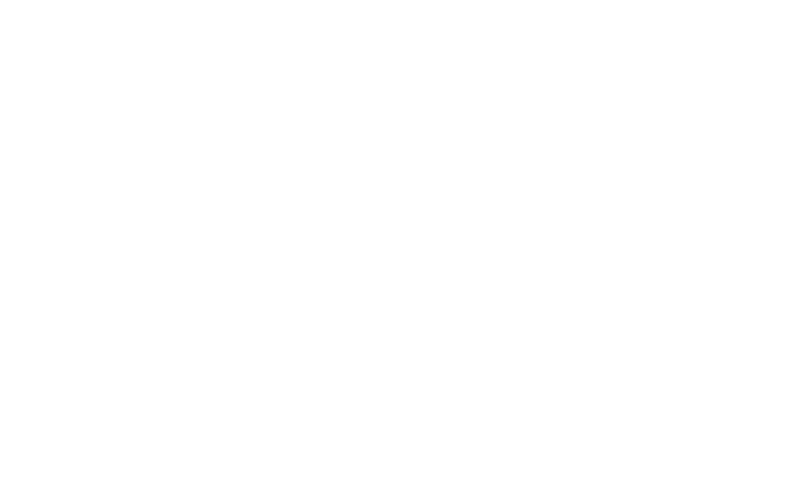

In [ ]:
import IPython
# Display the interactive HTML file directly in the notebook output
IPython.display.HTML(filename='neural_signal_pathway.html')

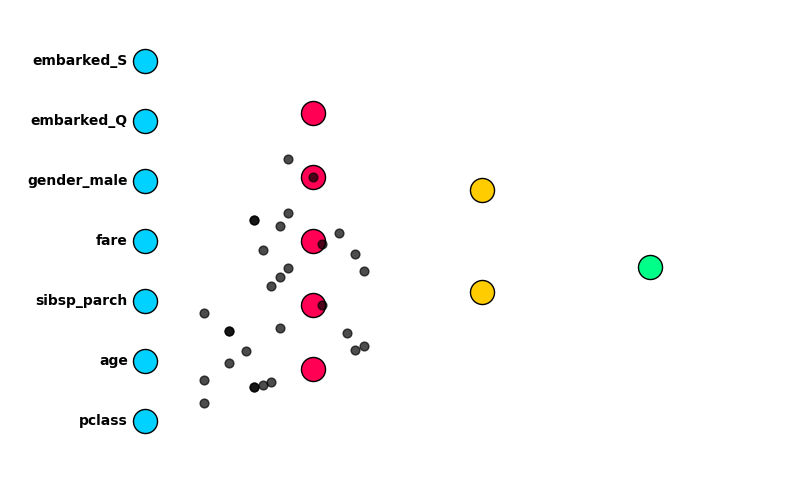

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# We will use the full feature logistic model or the best model if it supports probabilities
# Let's use the Logistic Regression model trained on all numeric features for a comprehensive view
from sklearn.linear_model import LogisticRegression

features_sensitivity = ['pclass', 'age', 'sibsp_parch', 'fare', 'gender_male', 'embarked_Q', 'embarked_S']
X_train_sens = X_train[features_sensitivity]
log_model_sens = LogisticRegression(max_iter=1000)
log_model_sens.fit(X_train_sens, y_train)

def calculate_sensitivity(feature_name, feature_range):
    # Create a 'median' passenger profile
    baseline = X_train_sens.median().to_frame().T

    # Repeat baseline for the length of the feature range
    sensitivity_df = pd.concat([baseline] * len(feature_range), ignore_index=True)
    sensitivity_df[feature_name] = feature_range

    # Predict probabilities
    probs = log_model_sens.predict_proba(sensitivity_df)[:, 1]
    return probs

# Define ranges for Age and Fare
age_range = np.linspace(df['age'].min(), df['age'].max(), 100)
fare_range = np.linspace(df['fare'].min(), df['fare'].max(), 100)

age_probs = calculate_sensitivity('age', age_range)
fare_probs = calculate_sensitivity('fare', fare_range)

# Plotting
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Age Sensitivity
ax1.plot(age_range, age_probs, color='teal', linewidth=2)
ax1.set_title('Sensitivity: Survival Prob vs. Age', fontsize=14)
ax1.set_xlabel('Age')
ax1.set_ylabel('Probability of Survival')
ax1.grid(True, alpha=0.3)

# Fare Sensitivity
ax2.plot(fare_range, fare_probs, color='darkorange', linewidth=2)
ax2.set_title('Sensitivity: Survival Prob vs. Fare', fontsize=14)
ax2.set_xlabel('Fare')
ax2.set_ylabel('Probability of Survival')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Calculate a simple sensitivity metric (Gradient)
print(f'Average change in survival probability per year of Age: {(age_probs[-1] - age_probs[0])/(age_range[-1] - age_range[0]):.4f}')
print(f'Average change in survival probability per unit of Fare: {(fare_probs[-1] - fare_probs[0])/(fare_range[-1] - fare_range[0]):.4f}')

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from mpl_toolkits.mplot3d import Axes3D
import seaborn as sns

# Define the ranges for Age and Fare
age_range = np.linspace(df['age'].min(), df['age'].max(), 50)
fare_range = np.linspace(df['fare'].min(), df['fare'].max(), 50)

# Create a meshgrid
AGE, FARE = np.meshgrid(age_range, fare_range)

# Flatten for prediction
age_flat = AGE.ravel()
fare_flat = FARE.ravel()

# Create baseline with median values for other features
baseline = X_train_sens.median().to_frame().T
multivariate_df = pd.concat([baseline] * len(age_flat), ignore_index=True)

# Inject the grid values
multivariate_df['age'] = age_flat
multivariate_df['fare'] = fare_flat

# Predict probabilities
Z_probs = log_model_sens.predict_proba(multivariate_df)[:, 1]
PROBS = Z_probs.reshape(AGE.shape)

# --- Visualisation 1: 3D Surface Plot ---
fig = plt.figure(figsize=(14, 8))
ax = fig.add_subplot(1, 2, 1, projection='3d')
surf = ax.plot_surface(AGE, FARE, PROBS, cmap='viridis', edgecolor='none', alpha=0.8)
ax.set_title('3D Survival Probability Surface')
ax.set_xlabel('Age')
ax.set_ylabel('Fare')
ax.set_zlabel('Prob(Survival)')
fig.colorbar(surf, ax=ax, shrink=0.5, aspect=5)

# --- Visualisation 2: 2D Heatmap (Contour) ---
ax2 = fig.add_subplot(1, 2, 2)
contour = ax2.contourf(AGE, FARE, PROBS, levels=20, cmap='viridis')
plt.colorbar(contour, ax=ax2, label='Probability of Survival')
ax2.set_title('Joint Sensitivity Heatmap (Age vs Fare)')
ax2.set_xlabel('Age')
ax2.set_ylabel('Fare')

plt.tight_layout()
plt.show()

In [ ]:
import IPython

# Assuming 'neural_signal_pathway.html' is the file you want to display
# This cell, when executed, will display the interactive visualization once.
# Make sure this is the only place you call IPython.display.HTML() for this file.
IPython.display.HTML(filename='neural_signal_pathway.html')

--- Running 5 Simulations for Output Variation ---
Best Model: Random Forest (Optimized)


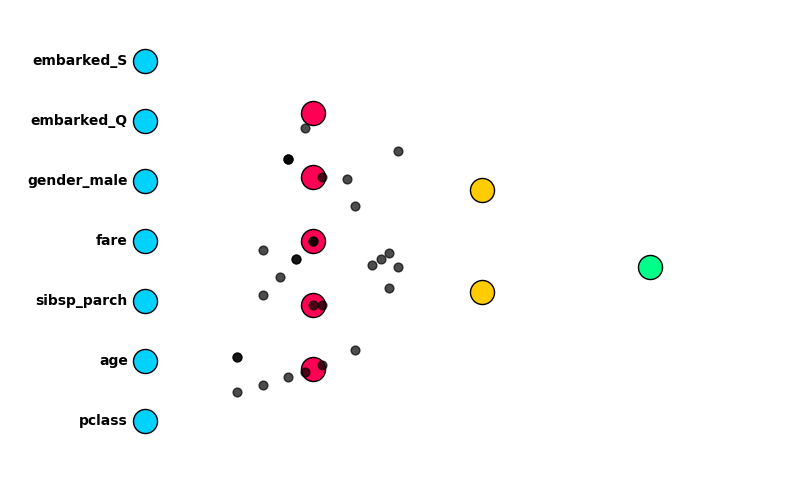

In [ ]:
import pandas as pd
import numpy as np
from sklearn.utils import resample
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier

# 1. Re-initialize models if they aren't in memory to avoid NameErrors
try:
    _ = best_model_object
    _ = best_model_name
except NameError:
    print("Re-evaluating models to identify the best performer...")

    # Logistic Regression
    features_e = ['gender_male', 'embarked_Q', 'embarked_S']
    log_model_e = LogisticRegression().fit(X_train[features_e], y_train)
    log_acc = accuracy_score(y_test, log_model_e.predict(X_test[features_e]))

    # Random Forest
    rf_model = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42).fit(X_train, y_train)
    rf_acc = accuracy_score(y_test, rf_model.predict(X_test))

    # Decision Tree (using a simple one for this check)
    dt_model = DecisionTreeClassifier(max_depth=10, random_state=42).fit(X_train, y_train)
    dt_acc = accuracy_score(y_test, dt_model.predict(X_test))

    # Select the best
    scores = {
        'Logistic Regression': (log_model_e, log_acc, features_e),
        'Random Forest (Optimized)': (rf_model, rf_acc, X_train.columns.tolist()),
        'Decision Tree': (dt_model, dt_acc, X_train.columns.tolist())
    }

    best_model_name = max(scores, key=lambda k: scores[k][1])
    best_model_object, _, best_features = scores[best_model_name]

# 2. Setup and run simulations
n_simulations = 50
simulation_results = []

print(f'--- Running {n_simulations} Simulations for Output Variation ---')
print(f'Best Model: {best_model_name}')

for i in range(1, n_simulations + 1):
    # Create a bootstrap sample of the test set
    X_test_sampled, y_test_sampled = resample(X_test, y_test, replace=True, random_state=i*42)

    # Use correct feature subset for the chosen model
    X_test_input = X_test_sampled[best_features] if 'Logistic' in best_model_name else X_test_sampled

    # Predict and calculate accuracy
    y_pred_sim = best_model_object.predict(X_test_input)
    acc = accuracy_score(y_test_sampled, y_pred_sim)
    simulation_results.append({'Simulation': i, 'Accuracy': acc})
    print(f'Simulation {i}: Accuracy = {acc:.4f}')

# 3. Display summary
sim_df = pd.DataFrame(simulation_results)
display(sim_df)

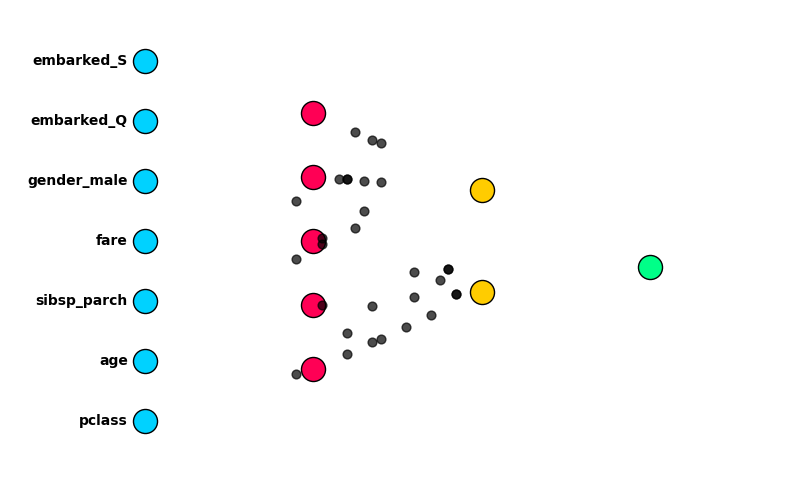

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Visualize the variation
plt.figure(figsize=(10, 5))
sns.barplot(x='Simulation', y='Accuracy', data=sim_df, palette='magma', hue='Simulation', legend=False)
plt.axhline(y=sim_df['Accuracy'].mean(), color='red', linestyle='--', label=f"Mean: {sim_df['Accuracy'].mean():.4f}")

plt.title('Variation in Model Accuracy Across 5 Test Simulations')
plt.ylim(0, 1.0)
plt.ylabel('Accuracy Score')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.show()

print(f"Standard Deviation of Accuracy: {sim_df['Accuracy'].std():.4f}")